# 02. 카드 데이터 EDA

## 이 노트북이 하는 일
날씨를 보기 전에 **카드 매출이 평소에 어떻게 생겼는지** 파악한다.
여기서 알아낸 요일, 연휴, 업종, 시간대 특성이 05번 노트북에서 날씨 효과를 가려낼 때 기준이 된다.

## 답해야 할 질문
1. 날씨 말고 매출을 움직이는 요인(요일, 연휴, 월)은 각각 얼마나 큰가?
2. 날씨 분석에 쓸 업종은 무엇이고, 결제가 0건인 날은 어떤 업종에 몰려 있는가?
3. 강남과 춘천의 소비 구조는 어떻게 다른가?
4. 춘천의 외지인 매출은 얼마나 되고, 언제 늘어나는가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 출력 |
|---|---|
| `card1.parquet`, `card2.parquet`, `calendar.parquet`, `industry_map.csv` | 그래프 (노트북 안), `card2_outsider_daily.parquet` (9장) |


01번 노트북을 먼저 실행해서 `preprocessed/` 폴더에 파일이 있어야 한다.

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path          # 파일 경로 다루기 (윈도우/맥 상관없이 동작)
import numpy as np                # 숫자 계산
import pandas as pd               # 표(DataFrame) 다루기
import matplotlib.pyplot as plt   # 그래프 그리기
import seaborn as sns             # 박스플롯, 히트맵 같은 통계 그래프를 쉽게 그려줌
from IPython.display import display   # 표를 칸이 나뉜 표로 보여줌 (print(표)는 글자로만 나와서 보기 불편함)

# ── 한글 폰트 설정 (안 하면 그래프의 한글이 네모로 깨짐) ──
plt.rc('font', family='Malgun Gothic')     # 윈도우 기본 한글 폰트
plt.rc('axes', unicode_minus=False)        # 한글 폰트를 쓰면 음수 부호(-)가 깨지는 것 방지

# ── 그래프 기본 크기와 선명도 ──
plt.rc('figure', figsize=(12, 4), dpi=110)  # 가로 12, 세로 4 (인치), dpi = 선명도

# ── 지역 색: 모든 그래프에서 같은 지역은 같은 색 ──
REGIONS = ['강남', '춘천']
REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}   # 파랑, 주황

# ── 표 출력 설정 ──
pd.set_option('display.float_format', '{:,.2f}'.format)   # 숫자에 쉼표, 소수 둘째 자리까지
pd.set_option('display.max_columns', 60)                  # 열이 많아도 중간을 ... 으로 생략하지 않음

print('pandas', pd.__version__)

pandas 2.2.3


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
# 01번 노트북과 같은 방식: 'dataset 폴더가 있는 곳'이 나올 때까지 상위 폴더로 올라가며 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:    # 드라이브 맨 위까지 올라갔는데도 없으면 멈춤
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'     # 01번이 정리한 파일이 있는 폴더

# 01번이 저장한 파일 4개 불러오기
card1 = pd.read_parquet(OUT / 'card1.parquet')            # 카드 데이터1 (시간대별)
card2 = pd.read_parquet(OUT / 'card2.parquet')            # 카드 데이터2 (고객 거주지별)
calendar = pd.read_parquet(OUT / 'calendar.parquet')      # 달력 (요일, 공휴일, 추석)
industry_map = pd.read_csv(OUT / 'industry_map.csv')      # 업종 -> 업종그룹, 분석 대상 여부

# 제대로 읽혔는지 크기(행 × 열) 확인
for name, df in {'card1': card1, 'card2': card2, 'calendar': calendar, 'industry_map': industry_map}.items():
    print(f'{name:13s} {df.shape[0]:>10,}행 × {df.shape[1]:>2}열  {list(df.columns)}')

card1          1,663,909행 × 11열  ['date', 'time_gb', 'region', 'industry', 'sex', 'age', 'amount', 'cnt', 'industry_group', 'is_target', 'is_filled']
card2          4,208,127행 × 11열  ['date', 'region', 'industry', 'residence', 'sex', 'age', 'amount', 'cnt', 'industry_group', 'is_target', 'is_filled']
calendar             184행 ×  9열  ['date', 'month', 'dow', 'dow_name', 'is_weekend', 'holiday_name', 'is_holiday', 'is_offday', 'is_chuseok_break']
industry_map          91행 ×  4열  ['industry', 'industry_group', 'is_target', 'exclude_reason']


### 0-3. 분석 기본 표 만들기 (날씨분석 대상 업종 x 개인 결제)

In [3]:
# 이 노트북 대부분은 "날씨 분석 대상 업종 + 개인 결제"만 본다. 매번 조건을 쓰지 않도록 미리 잘라 둔다.
base1 = card1[card1['is_target'] & card1['sex'].ne('법인')].copy()   # .ne('법인') = "법인이 아닌가?"
base2 = card2[card2['is_target']].copy()                             # card2에는 법인이 원래 없음
# .copy(): 잘라낸 표를 원본과 엮이지 않은 새 표로 만듦 (나중에 열을 추가할 때 경고가 안 뜨게)

# 달력을 날짜로 찾기 쉽게 date를 행 이름(index)으로 둔다. 일별 표를 만든 뒤 .join(cal)로 붙이면 된다.
cal = calendar.set_index('date')

print(f"base1 행 수: card1의 {len(base1) / len(card1):.1%}")
print(f"base1 금액: card1 전체 금액의 {base1['amount'].sum() / card1['amount'].sum():.1%}")
print(f"base2 행 수: {len(base2):,}")

base1 행 수: card1의 77.3%
base1 금액: card1 전체 금액의 31.1%
base2 행 수: 3,494,167


## 1. 데이터 개요
두 지역의 매출 규모와, 어떤 결제를 빼고 분석하는지 한눈에 본다.

### 1-1. 지역별 규모 표

In [4]:
def size_table(df):
    """지역별 행 수, 금액 합계(억 원), 건수 합계, 일평균 금액(억 원)을 표로 만든다."""
    t = df.groupby('region').agg(행수=('amount', 'size'), 금액=('amount', 'sum'), 건수=('cnt', 'sum'))
    # agg(새 이름=('열', '계산')): 한 번에 여러 계산. size=행 수 세기, sum=합계
    t['금액'] = t['금액'] / 1e8                  # 원 -> 억 원
    t['일평균금액'] = t['금액'] / len(cal)       # 184일로 나누기
    return t

# 두 표를 옆으로 붙인다. 열 이름 위에 'card1 전체', 'base1' 이 한 줄 더 붙음
size = pd.concat({'card1 전체': size_table(card1), 'base1 (대상 업종 + 개인)': size_table(base1)}, axis=1)
display(size)

# 강남이 춘천의 몇 배인가
for name in ['card1 전체', 'base1 (대상 업종 + 개인)']:
    amt = size[(name, '금액')]
    print(f"{name}: 강남 / 춘천 = {amt['강남'] / amt['춘천']:.1f}배")

card1 전체                                base1 (대상 업종 + 개인)            \
             행수         금액         건수    일평균금액                 행수        금액   
region                                                                        
강남       962415 334,941.38  559119775 1,820.33             713652 96,824.57   
춘천       701494  23,717.19   53230585   128.90             571797 14,660.31   

                          
               건수  일평균금액  
region                    
강남      316358823 526.22  
춘천       48516630  79.68

card1 전체: 강남 / 춘천 = 14.1배
base1 (대상 업종 + 개인): 강남 / 춘천 = 6.6배


### 1-2. 빠지는 결제의 크기

part,제외 업종,대상 업종 법인,대상 업종 개인
region,,,
강남,65.30,5.70,28.90
춘천,28.90,9.30,61.80
전체,62.90,6.00,31.10


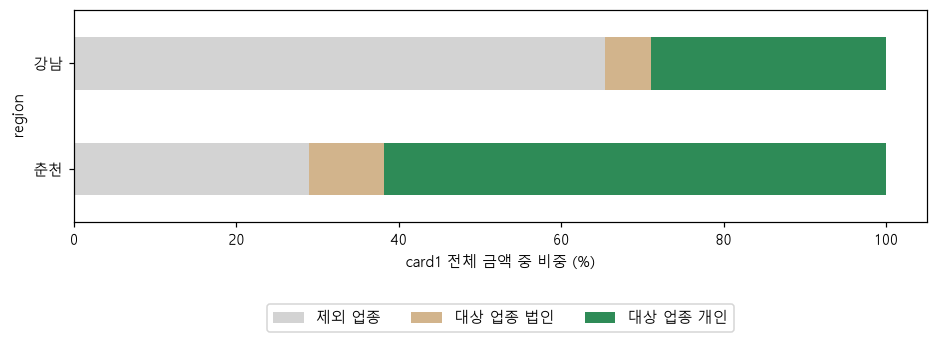

In [5]:
# card1의 모든 행을 세 덩어리 중 하나로 나눈다.
# np.select([조건1, 조건2], [값1, 값2], default=나머지 값): 조건을 위에서부터 차례로 확인 (중첩 IF와 비슷)
part = np.select(
    [~card1['is_target'], card1['sex'].eq('법인')],       # ~ = 반대. 분석 대상이 아니면 -> 제외 업종
    ['제외 업종', '대상 업종 법인'],
    default='대상 업종 개인',                              # 나머지 = base1
)
ORDER = ['제외 업종', '대상 업종 법인', '대상 업종 개인']

amt = card1.assign(part=part).pivot_table(index='region', columns='part', values='amount', aggfunc='sum')[ORDER]
amt.loc['전체'] = amt.sum()                                   # 맨 아래에 두 지역 합계 줄 추가
share = amt.div(amt.sum(axis=1), axis=0) * 100               # 행마다 합이 100이 되게 (%)
display(share.round(1))

# 가로 누적 막대: 막대 하나 = 지역 하나, 색 = 세 덩어리
ax = share.loc[REGIONS].plot(kind='barh', stacked=True, figsize=(10, 2.5), color=['lightgray', 'tan', 'seagreen'])
ax.set_xlabel('card1 전체 금액 중 비중 (%)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3)   # 범례를 그래프 아래로
ax.invert_yaxis()                                                     # 강남이 위에 오게
plt.show()

# 각 region별로 part를 더해도 100이 안되는 이유는 각 값을 반올림하면서 계산해서 그럼. 실제로는 100%임

## 2. 결제가 0건인 칸 확인

01번 3-2에서 **그날 결제가 없던 칸을 0으로 채워** 두었다(`is_filled=True`). 그래서 이제 빠지는 칸은 없다.
다만 **어떤 칸이 자주 0이 되는지**는 알아야 한다. 0이 잦은 업종은 하루 단위로 보면 들쭉날쭉해서 날씨 효과를 읽기 어렵다.

### 2-1. 일별 '결제가 있던 칸' 수 추이
채운 행을 빼고, 실제로 결제가 일어난 칸이 날마다 몇 개인지 본다.

region,강남,춘천
count,184.00,184.00
mean,"3,596.00","2,081.00"
std,151.00,113.00
min,"2,671.00","1,597.00"
25%,"3,592.00","2,045.00"
50%,"3,636.00","2,114.00"
75%,"3,689.00","2,154.00"
max,"3,787.00","2,249.00"


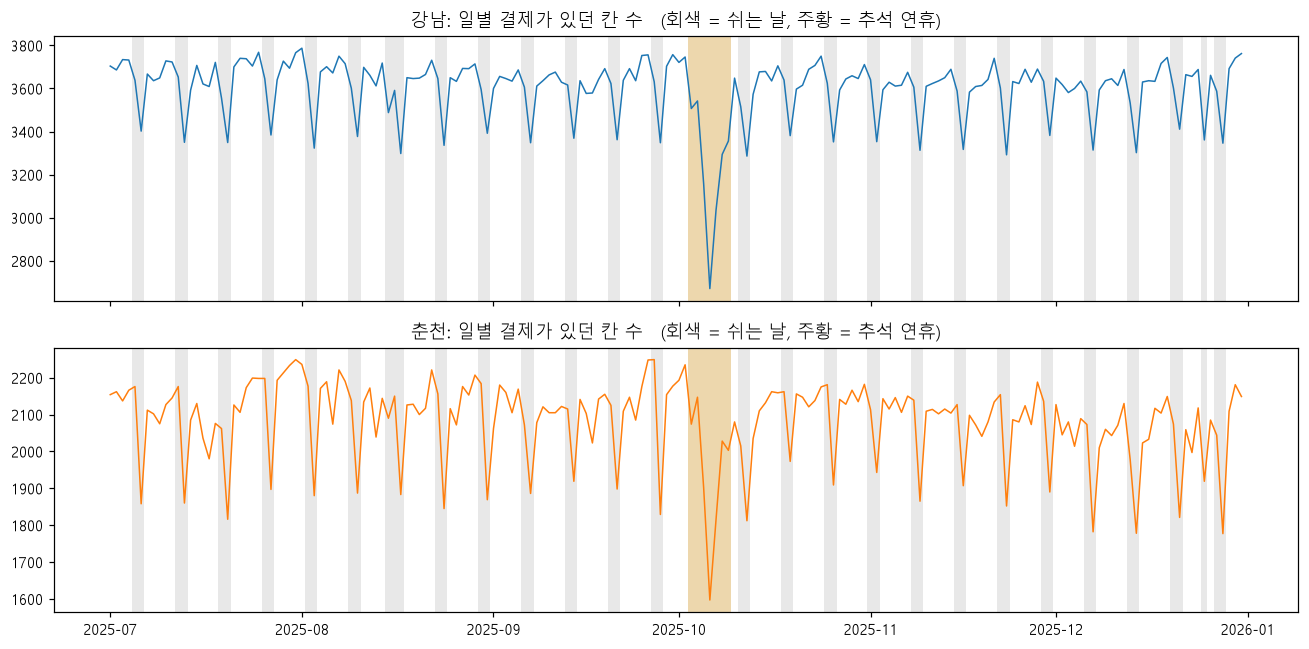

,월,화,수,목,금,토,일
region,,,,,,,
강남,"3,598.00","3,638.00","3,646.00","3,653.00","3,692.00","3,605.00","3,340.00"
춘천,"2,088.00","2,107.00","2,111.00","2,116.00","2,151.00","2,128.00","1,867.00"


행이 가장 적은 날: 2025-10-06


In [6]:
# 지역 × 날짜별 '결제가 있던 칸' 수. 적은 날 = 문을 닫거나 결제가 0건인 칸이 많은 날
rows = (card1[~card1['is_filled']].groupby(['date', 'region']).size()
        .unstack('region'))   # unstack: region 값을 열로 펼치기 -> 열이 강남, 춘천
display(rows.describe().round(0))

def shade_days(ax):
    """그래프(ax)에 쉬는 날(주말과 공휴일)은 회색, 추석 연휴(10/3 ~ 10/9)는 주황 배경을 칠한다."""
    half = pd.Timedelta(hours=12)                      # 하루 칸의 절반. 날짜 앞뒤로 12시간씩 칠해서 하루 폭이 되게
    for d in cal.index[cal['is_offday']]:
        ax.axvspan(d - half, d + half, color='lightgray', alpha=0.5, lw=0)   # axvspan: x축 구간에 세로 띠 칠하기
    ch = cal.index[cal['is_chuseok_break']]
    ax.axvspan(ch.min() - half, ch.max() + half, color='orange', alpha=0.25, lw=0)


# 지역마다 규모가 달라서 그래프를 위아래 2개로 나눈다
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)        # sharex: 두 그래프의 x축(날짜)을 맞춤
for ax, r in zip(axes, REGIONS):                                     # zip: 두 목록을 짝지어 하나씩 꺼냄
    shade_days(ax)                                                   # 쉬는 날 회색, 추석 주황 (0-3에서 만든 함수)
    ax.plot(rows.index, rows[r], color=REGION_COLOR[r], lw=1)
    ax.set_title(f'{r}: 일별 결제가 있던 칸 수   (회색 = 쉬는 날, 주황 = 추석 연휴)')
plt.tight_layout()                                                   # 그래프끼리 겹치지 않게 간격 자동 조정
plt.show()

# 요일별 평균 행 수 (0=월 ... 6=일)
by_dow = rows.groupby(rows.index.dayofweek).mean().round(0)
by_dow.index = list('월화수목금토일')
display(by_dow.T)                                                    # .T: 행과 열 뒤집기 (가로로 보기 편하게)
print('행이 가장 적은 날:', rows.sum(axis=1).idxmin().date())       # idxmin: 가장 작은 값이 있는 위치(날짜)

시사점: 평소에는 결제가 있던 칸 수가 거의 일정하고, 매주 일요일마다 한 번씩 줄어드는 톱니 모양이 반복된다.
그중 추석 연휴(특히 10/6 추석 당일)에 가장 크게 줄어든다. **문을 닫는 날이 그대로 드러난 것**이다.

### 2-3. 0으로 채운 칸이 얼마나 되나
`is_filled` 비중이 높을수록 **결제가 없는 날이 잦은** 칸이다. 업종그룹별로 얼마나 다른지 본다.

,0인 날 비중
region,
강남,30.7%
춘천,41.9%


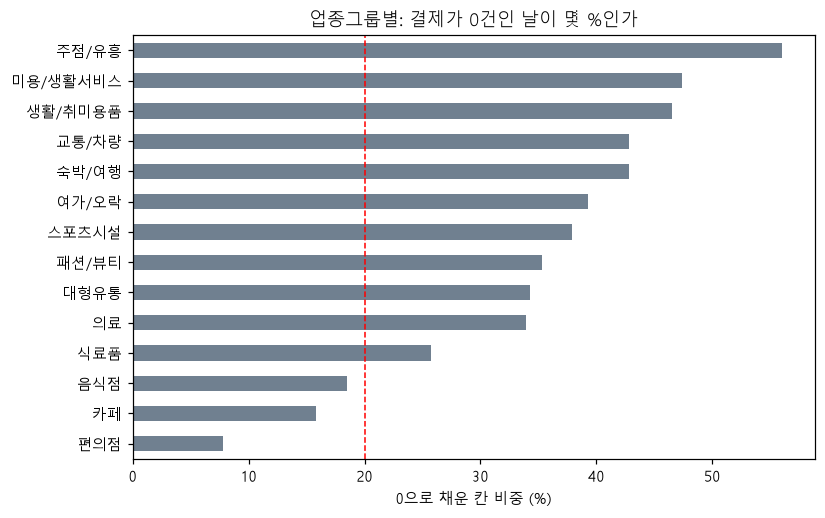

In [7]:
CELL1 = ['region', 'industry', 'sex', 'age', 'time_gb']      # 칸을 정하는 5개 항목 (날짜 제외)

zero_region = base1.groupby('region')['is_filled'].mean().rename('0인 날 비중')
display(zero_region.to_frame().map('{:.1%}'.format))

# 업종그룹별 0인 날 비중 -> 높을수록 하루 단위로 들쭉날쭉한 업종
zero_group = base1.groupby('industry_group')['is_filled'].mean().sort_values()
ax = zero_group.mul(100).plot(kind='barh', figsize=(8, 5), color='slategray')
ax.set(xlabel='0으로 채운 칸 비중 (%)', ylabel='', title='업종그룹별: 결제가 0건인 날이 몇 %인가')
ax.axvline(20, ls='--', color='red', lw=1)                 # 20% 기준선
plt.show()

시사점: 0인 날 비중이 낮은 업종(편의점, 카페, 음식점, 식료품)은 매일 꾸준히 결제가 일어나는 일상 소비 업종이다.
날씨 효과를 하루 단위로 읽기에 가장 안정적이다.

### 2-4. 작은 칸일수록 0인 날이 잦은가
칸의 평균 결제건수와 0인 날 비중의 관계를 본다. 작은 칸일수록 0이 잦다면, 업종을 고를 때 규모도 같이 봐야 한다.

In [8]:
칸별 = (base1.groupby(CELL1, observed=True)
        .agg(평균건수=('cnt', 'mean'), 영업일=('is_filled', lambda s: (~s).sum()), 일수=('is_filled', 'size')))
칸별['0인 날 비중'] = 1 - 칸별['영업일'] / 칸별['일수']

구간 = pd.cut(칸별['평균건수'], [0, 10, 20, 50, 100, 10**9],
              labels=['~10건', '10~20건', '20~50건', '50~100건', '100건 이상'])
display(칸별.groupby(구간, observed=True)
        .agg(칸수=('0인 날 비중', 'size'), **{'0인 날 비중 평균': ('0인 날 비중', 'mean')})
        .assign(**{'0인 날 비중 평균': lambda d: d['0인 날 비중 평균'].map('{:.1%}'.format)}))

,칸수,0인 날 비중 평균
평균건수,,
~10건,4214,67.2%
10~20건,729,15.6%
20~50건,947,5.0%
50~100건,560,1.6%
100건 이상,1519,0.3%


시사점: 칸이 작을수록 0인 날이 잦다. 편의점, 카페, 음식점, 식료품처럼 칸이 크고 0이 드문 업종이
날씨 분석에서 가장 믿을 만하고, 주점/유흥과 여가/오락은 0인 날이 많아 결과를 조심해서 읽어야 한다.

## 3. 일별 매출 추이
184일 동안 매출이 어떻게 움직였는지 본다. 두 지역은 규모가 6~7배 차이 나므로 로그 스케일이나 지수로 비교한다.

### 3-1. 지역별 일매출 선그래프

region,강남,춘천
count,184.00,184.00
mean,526.00,80.00
std,97.00,11.00
min,145.00,55.00
25%,495.00,72.00
50%,539.00,77.00
75%,581.00,86.00
max,768.00,117.00


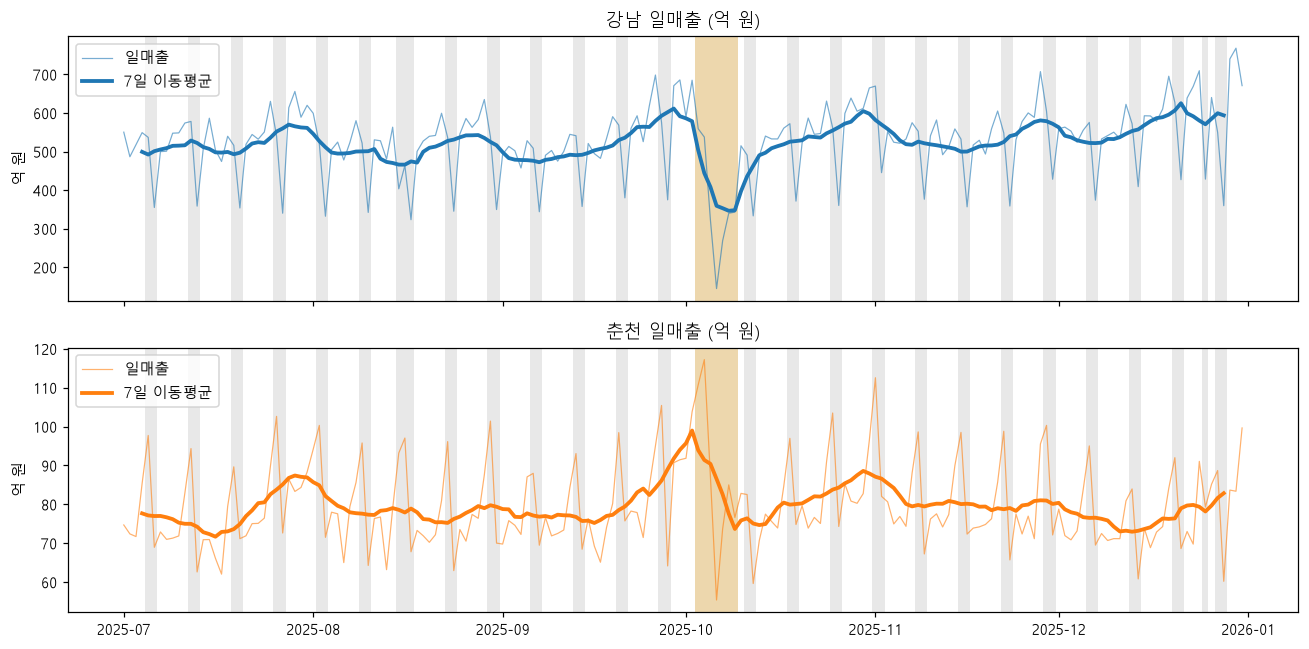

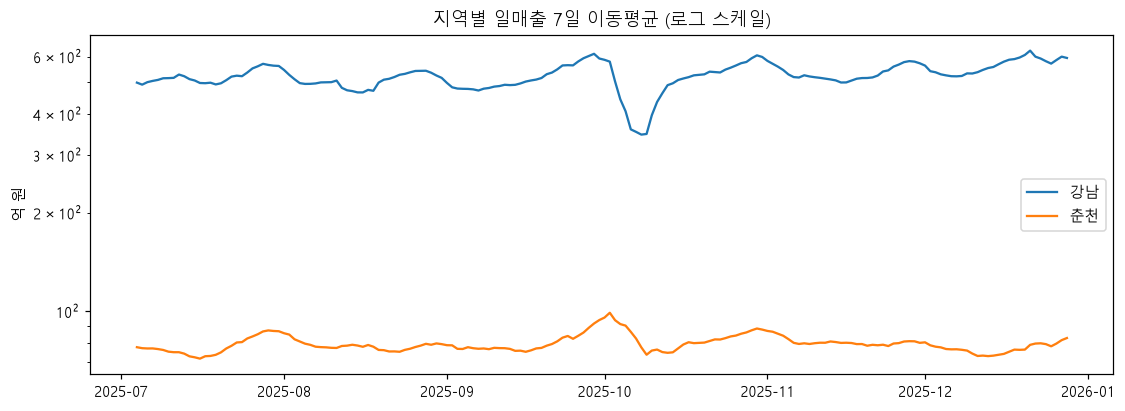

In [9]:
# 지역 × 날짜별 base1 금액 합계 (억 원). 3장과 4장에서 계속 쓰므로 daily 라는 이름으로 둔다.
daily = base1.groupby(['date', 'region'])['amount'].sum().unstack('region') / 1e8
display(daily.describe().round(0))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, r in zip(axes, REGIONS):
    shade_days(ax)
    ax.plot(daily.index, daily[r], color=REGION_COLOR[r], lw=0.8, alpha=0.6, label='일매출')
    # rolling(7, center=True).mean(): 그날을 가운데 두고 앞뒤 7일 평균 -> 요일 때문에 생기는 변동성을 없애고 큰 흐름만 봄
    ax.plot(daily.index, daily[r].rolling(7, center=True).mean(), color=REGION_COLOR[r], lw=2.5, label='7일 이동평균')
    ax.set(title=f'{r} 일매출 (억 원)', ylabel='억 원')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 두 지역을 한 그래프에: 규모가 6~7배 차이 나서 y축을 로그 스케일로
fig, ax = plt.subplots()
for r in REGIONS:
    ax.plot(daily.index, daily[r].rolling(7, center=True).mean(), color=REGION_COLOR[r], label=r)
ax.set_yscale('log')                              # 로그 스케일: 같은 "비율" 변화가 같은 높이로 보임
ax.set(title='지역별 일매출 7일 이동평균 (로그 스케일)', ylabel='억 원')
ax.legend()
plt.show()

#### 추석 연휴 전후 매출 변화 (3-1 보충)
3-1 그래프로는 추석 전후에 매출이 얼마나 변했는지 정확히 읽기 어렵다.

그래서 **추석 연휴 7일**을 **바로 앞 7일**, **바로 뒤 7일**과 숫자로 비교한다.

,앞 7일 (9/26~10/2),추석 연휴 (10/3~10/9),뒤 7일 (10/10~10/16)
region,,,
강남,611.70,359.50,490.60
춘천,91.80,86.50,74.70


,연휴 - 앞 (억 원),뒤 - 연휴 (억 원),연휴 vs 앞 (%),뒤 vs 연휴 (%),뒤 vs 앞 (%)
region,,,,,
강남,-252.20,131.10,-41.20,36.50,-19.80
춘천,-5.20,-11.90,-5.70,-13.70,-18.60


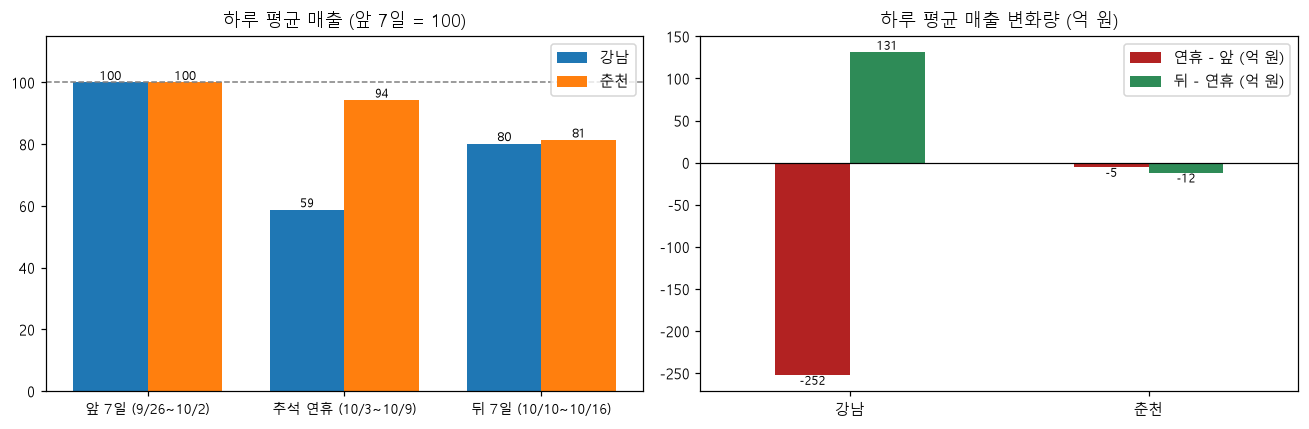

In [10]:
# 추석 연휴 7일과, 바로 앞 7일, 바로 뒤 7일의 하루 평균 매출을 비교한다.
# 7일씩 자르면 월~일 요일이 한 번씩 들어가서 요일 효과가 세 구간에 공평하게 섞인다.
PERIODS = {
    '앞 7일 (9/26~10/2)':    ('2025-09-26', '2025-10-02'),
    '추석 연휴 (10/3~10/9)': ('2025-10-03', '2025-10-09'),
    '뒤 7일 (10/10~10/16)':  ('2025-10-10', '2025-10-16'),
}
names = list(PERIODS)

# 1) 구간별 하루 평균 매출 (억 원). daily는 2-2에서 만든 지역 × 날짜별 매출
avg = pd.DataFrame({name: daily.loc[start:end].mean() for name, (start, end) in PERIODS.items()})
display(avg.round(1))

# 2) 변화량: 억 원과 %
change = pd.DataFrame({
    '연휴 - 앞 (억 원)': avg[names[1]] - avg[names[0]],
    '뒤 - 연휴 (억 원)': avg[names[2]] - avg[names[1]],
    '연휴 vs 앞 (%)':    (avg[names[1]] / avg[names[0]] - 1) * 100,
    '뒤 vs 연휴 (%)':    (avg[names[2]] / avg[names[1]] - 1) * 100,
    '뒤 vs 앞 (%)':      (avg[names[2]] / avg[names[0]] - 1) * 100,
})
display(change.round(1))

# 3) 그래프: 두 지역을 "앞 7일 = 100"으로 맞춰서 같은 눈금으로 비교
#    3-1처럼 지역마다 눈금이 다르면, 강남의 큰 하락과 춘천의 작은 하락이 비슷해 보이는 문제가 없어짐
idx = avg.div(avg[names[0]], axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = np.arange(len(names))                         # 막대 위치 0, 1, 2
w = 0.38                                          # 막대 너비
for k, r in enumerate(REGIONS):
    bars = ax.bar(x + (k - 0.5) * w, idx.loc[r], width=w, color=REGION_COLOR[r], label=r)
    ax.bar_label(bars, fmt='%.0f', fontsize=8)    # 막대 위에 숫자 쓰기
ax.axhline(100, ls='--', color='gray', lw=1)
ax.set_xticks(x, names, fontsize=9)
ax.set(title='하루 평균 매출 (앞 7일 = 100)', ylim=(0, 115))
ax.legend()

# 오른쪽: 실제 금액 변화 (억 원). 규모 차이가 그대로 보임
ax = axes[1]
diff = change[['연휴 - 앞 (억 원)', '뒤 - 연휴 (억 원)']]
diff.plot(kind='bar', ax=ax, color=['firebrick', 'seagreen'], rot=0)
ax.axhline(0, color='black', lw=0.8)
ax.set(title='하루 평균 매출 변화량 (억 원)', xlabel='')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', fontsize=8)
plt.tight_layout()
plt.show()

시사점: 매출은 요일의 영향을 많이 받아서 7일 이동평균선으로 보면 강남과 춘천 모두 월말에 오르는 경향을 보인다. 추석 연휴에는 강남 매출이 직전 7일보다 41.2% 줄었지만 춘천은 5.7% 줄어들어서, 연휴 충격이 강남에서 약 7배 컸다.

### 3-3. 매출이 특이했던 날 찾기

In [11]:
# 지역별로 일매출이 가장 낮은 5일과 가장 높은 5일. 달력을 붙여서 요일과 공휴일을 같이 본다.
for r in REGIONS:
    for label, days in [('최저', daily[r].nsmallest(5)), ('최고', daily[r].nlargest(5))]:
        t = days.rename('매출(억 원)').to_frame().join(cal[['dow_name', 'holiday_name']])
        t.index = t.index.strftime('%m/%d')          # 날짜를 '10/06' 모양으로 짧게
        print(f'{r} {label} 5일')
        display(t.round(0))

강남 최저 5일


,매출(억 원),dow_name,holiday_name
date,,,
10/06,145.00,월,추석
10/07,269.00,화,추석 연휴
10/05,322.00,일,추석 연휴
08/17,323.00,일,
08/03,332.00,일,


강남 최고 5일


,매출(억 원),dow_name,holiday_name
date,,,
12/30,768.00,화,
12/29,740.00,월,
12/24,710.00,수,
11/28,707.00,금,
09/26,699.00,금,


춘천 최저 5일


,매출(억 원),dow_name,holiday_name
date,,,
10/06,55.00,월,추석
10/12,60.00,일,
12/28,60.00,일,
12/14,61.00,일,
07/17,62.00,목,


춘천 최고 5일


,매출(억 원),dow_name,holiday_name
date,,,
10/04,117.00,토,
11/01,113.00,토,
10/03,111.00,금,개천절
09/27,105.00,토,
10/02,104.00,목,


시사점: 강남은 추석 연휴와 8월 휴가철 일요일에 매출이 가장 낮고 연말과 월말에 가장 높은 반면, 춘천은 토요일과 추석 연휴 직전에 가장 높다.

[특이한 날들]
- 춘천 7/17은 평일인데 최저 5위였다. 아직 기상 데이터 EDA를 제대로 하지 않았지만, 구글 검색 결과 2025년 7월 17일에 춘천시에 집중 호우로 인한 호우 주의보가 발효되었다고한다.
- 8/3에는 기상특보는 없었지만 전날 비가 왔고 34도 내외의 고온다습한 환경이었다. (상원님이 말한 불쾌 지수같은 지수를 매출-기상 분석에 넣어도 좋을듯)
- 8/17에는 전국적으로 폭염주의보가 발효되었었다.
- 9/26에 코엑스에서 2025 강남페스티벌 개막제가 열렸다.
- 9/27에 춘천에서는 제 46회 소양강 문화제 행사가 열렸다.

### 3-4. 월별 평균

,7월,8월,9월,10월,11월,12월
region,,,,,,
강남,523.00,504.00,521.00,503.00,533.00,573.00
춘천,78.00,79.00,79.00,83.00,81.00,78.00


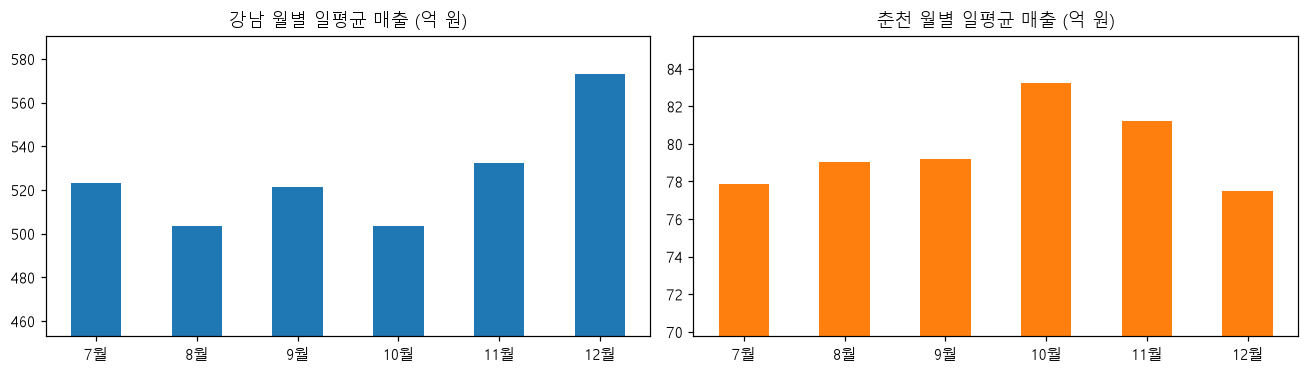

In [12]:
# 지역 × 월별 일평균 매출 (억 원)
monthly = daily.groupby(daily.index.month).mean()
monthly.index = [f'{m}월' for m in monthly.index]
display(monthly.round(0).T)

# 두 지역 규모가 달라서 그래프를 나란히 2개로
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, r in zip(axes, REGIONS):
    monthly[r].plot(kind='bar', ax=ax, color=REGION_COLOR[r], rot=0)   # rot=0: x축 글자를 눕히지 않음
    ax.set(title=f'{r} 월별 일평균 매출 (억 원)', ylim=(monthly[r].min() * 0.9, monthly[r].max() * 1.03))
    # ylim: y축 범위. 0부터 그리면 차이가 안 보여서 최솟값 근처부터 그림 (눈금 읽을 때 주의)
plt.tight_layout()
plt.show()

## 4. 요일과 휴일 효과 (요일, 공휴일)
날씨 효과를 보려면 요일과 연휴 효과를 먼저 걷어내야한다.

### 4-1. 요일별 매출

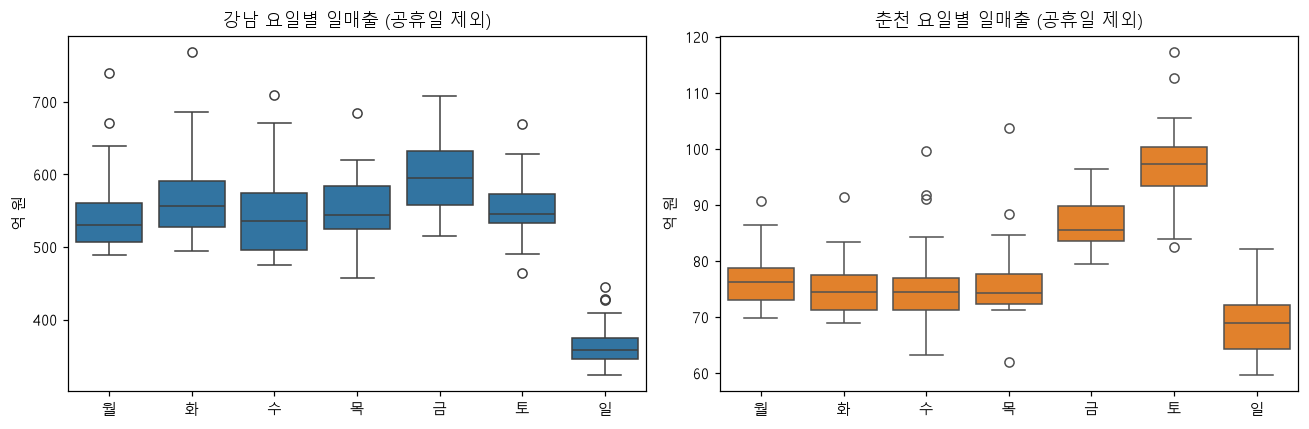

dow_name,월,화,수,목,금,토,일
강남,1.03,1.07,1.02,1.04,1.12,1.03,0.69
춘천,0.97,0.94,0.95,0.96,1.09,1.22,0.86


In [13]:
# 일별 매출에 달력 붙이기 (날짜 기준)
dd = daily.join(cal)
normal = dd[~dd['is_holiday']]                    # 공휴일은 요일 효과를 흐리므로 뺌
DOW = list('월화수목금토일')

# 지역별 요일 박스플롯: 상자 = 가운데 50% 날들, 가운데 선 = 중앙값, 점 = 튀는 날
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r in zip(axes, REGIONS):
    sns.boxplot(data=normal, x='dow_name', y=r, order=DOW, ax=ax, color=REGION_COLOR[r])
    ax.set(title=f'{r} 요일별 일매출 (공휴일 제외)', xlabel='', ylabel='억 원')
plt.tight_layout()
plt.show()

# 요일 평균 / 전체 평균: 1보다 크면 평균보다 잘 팔리는 요일
dow_ratio = normal.groupby('dow_name')[REGIONS].mean().reindex(DOW) / normal[REGIONS].mean()
display(dow_ratio.round(2).T)

시사점: 강남은 월~토 매출이 비슷하고 일요일만 평균보다 31% 낮다. 춘천은 토요일이 평균보다 22% 높다. 두 지역 모두 토요일에서 일요일로 넘어가면 매출이 약 30% 떨어지지만, 춘천의 일요일은 평균보다 14%만 낮아 강남(31%)보다 덜 낮다. 박스플롯의 위쪽 이상치는 대부분 월말과 연말이라, 날씨 효과를 볼 때 요일과 공휴일뿐 아니라 월말도 통제해야 한다.

### 4-2. 공휴일 효과

,dow_name,holiday_name,강남,춘천
date,,,,
08/15,금,광복절,0.67,1.08
10/03,금,개천절,0.93,1.28
10/05,일,추석 연휴,0.88,1.27
10/06,월,추석,0.26,0.72
10/07,화,추석 연휴,0.47,0.98
10/08,수,대체공휴일(추석),0.63,1.13
10/09,목,한글날,0.62,1.00
12/25,목,성탄절,0.78,1.04


공휴일 전체 평균: {'강남': 0.65, '춘천': 1.06}
추석 연휴를 뺀 공휴일 평균(광복절, 성탄절): {'강남': 0.72, '춘천': 1.06}


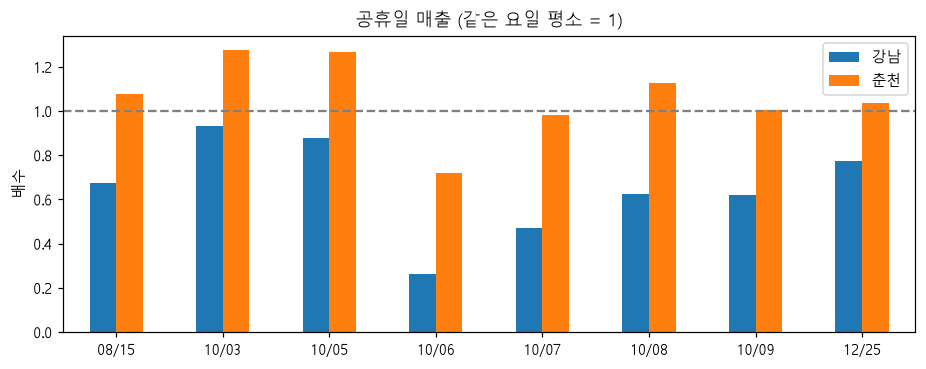

In [14]:
# 공휴일 하루하루를 "같은 요일의 평소 매출"과 비교한다.
# 평일 평균과 비교하면 일요일 공휴일(10/5)이 불리하게 나오므로, 요일을 맞춰서 비교해야 한다.
base = daily[~dd['is_holiday']]                                   # 공휴일이 아닌 날 (주말 포함)
dow_mean = base.groupby(dd.loc[base.index, 'dow']).mean()         # 요일별 평소 매출

hol = dd[dd['is_holiday']]
ratio = daily.loc[hol.index] / dow_mean.loc[hol['dow']].values     # 공휴일 / 같은 요일 평소
ratio = ratio.join(hol[['dow_name', 'holiday_name']])
ratio.index = ratio.index.strftime('%m/%d')
display(ratio[['dow_name', 'holiday_name'] + REGIONS].round(2))

# 추석 연휴에 속한 공휴일을 빼고, 나머지 공휴일(광복절, 성탄절)만 평균
solo = hol[~hol['is_chuseok_break']].index
print('공휴일 전체 평균:', (daily.loc[hol.index] / dow_mean.loc[hol['dow']].values).mean().round(2).to_dict())
print('추석 연휴를 뺀 공휴일 평균(광복절, 성탄절):',
      (daily.loc[solo] / dow_mean.loc[dd.loc[solo, 'dow']].values).mean().round(2).to_dict())

# 막대그래프: 공휴일마다 두 지역을 나란히
ax = ratio[REGIONS].plot(kind='bar', figsize=(10, 3.5), color=REGION_COLOR, rot=0)
ax.axhline(1, ls='--', color='gray')                              # 1 = 같은 요일의 평소 수준
ax.set(title='공휴일 매출 (같은 요일 평소 = 1)', xlabel='', ylabel='배수')
plt.show()

시사점: 공휴일에는 강남 매출이 같은 요일 평소의 0.60.8배로 줄고, 춘천은 1.01.3배로 유지되거나 늘어 두 지역이 반대로 움직인다. 추석 연휴를 뺀 공휴일(광복절, 성탄절)만 봐도 강남 0.72배, 춘천 1.06배로 같은 방향이라 추석 때문만은 아니다. 가장 낮은 날은 두 지역 모두 추석 당일이다(강남 0.26배, 춘천 0.72배).

### 4-3. 요일 보정 매출 만들기

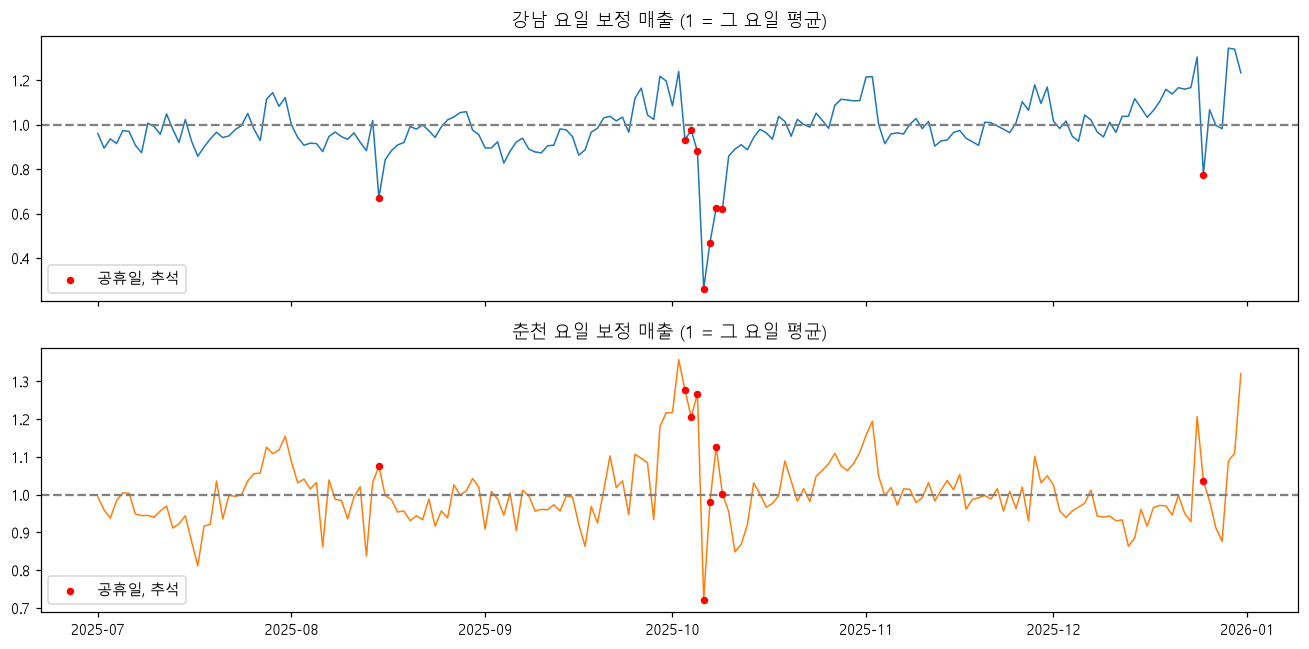

일매출 변동(표준편차 / 평균): {'강남': 0.165, '춘천': 0.134}
요일 보정 후 표준편차:         {'강남': 0.096, '춘천': 0.08}


In [15]:
# 1) 지역 × 요일별 평균 매출 (공휴일 제외) — 4-1의 normal 사용
dow_mean = normal.groupby('dow')[REGIONS].mean()           # 행 = 요일 번호(0~6), 열 = 지역

# 2) 요일 보정 매출 = 그날 매출 / 그 요일의 평균 매출. 1보다 크면 "그 요일치고 많이 팔린 날"
#    dow_mean.loc[dd['dow']]: 날마다 그날 요일의 평균을 한 줄씩 가져옴 -> 날짜 순서 그대로 나눌 수 있음
daily_adj = daily / dow_mean.loc[dd['dow']].values

# 3) 선그래프 + 공휴일과 추석은 점으로 표시
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
hol = dd['is_holiday'] | dd['is_chuseok_break']
for ax, r in zip(axes, REGIONS):
    ax.plot(daily_adj.index, daily_adj[r], color=REGION_COLOR[r], lw=1)
    ax.scatter(daily_adj.index[hol], daily_adj.loc[hol, r], color='red', s=15, zorder=3, label='공휴일, 추석')
    ax.axhline(1, ls='--', color='gray')
    ax.set(title=f'{r} 요일 보정 매출 (1 = 그 요일 평균)')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 변동성이 얼마나 줄었나: 표준편차 비교 (공휴일 제외)
print('일매출 변동(표준편차 / 평균):', (daily[~hol].std() / daily[~hol].mean()).round(3).to_dict())
print('요일 보정 후 표준편차:        ', daily_adj[~hol].std().round(3).to_dict())

시사점: 요일 효과를 빼니 일매출 변동 표준편차가 줄었다.하지만 요일을 빼도 연말과 연휴 앞뒤 효과가 크게 남아서, 날씨 효과를 보려면 공휴일, 연휴 전후, 월말까지 함께 통제해야 한다.

## 5. 업종 구조
어떤 업종이 매출을 이끄는지, 두 지역이 어떻게 다른지 본다. 날씨 분석에 쓸 업종 후보도 여기서 좁힌다.

### 5-1. 파레토 법칙 (상위 몇 개 업종이 매출의 80%인가)

강남: 업종 67개 중 상위 15개가 매출의 80%
   상위 5개: 일반병원 15.8%, 할인점/슈퍼마켓/양판점 11.3%, 쇼핑몰 10.5%, 한식 6.8%, 기타의료 5.6%
춘천: 업종 66개 중 상위 17개가 매출의 80%
   상위 5개: 할인점/슈퍼마켓/양판점 16.7%, 한식 15.5%, 주유소 9.0%, 기타요식 6.1%, 편의점 5.6%


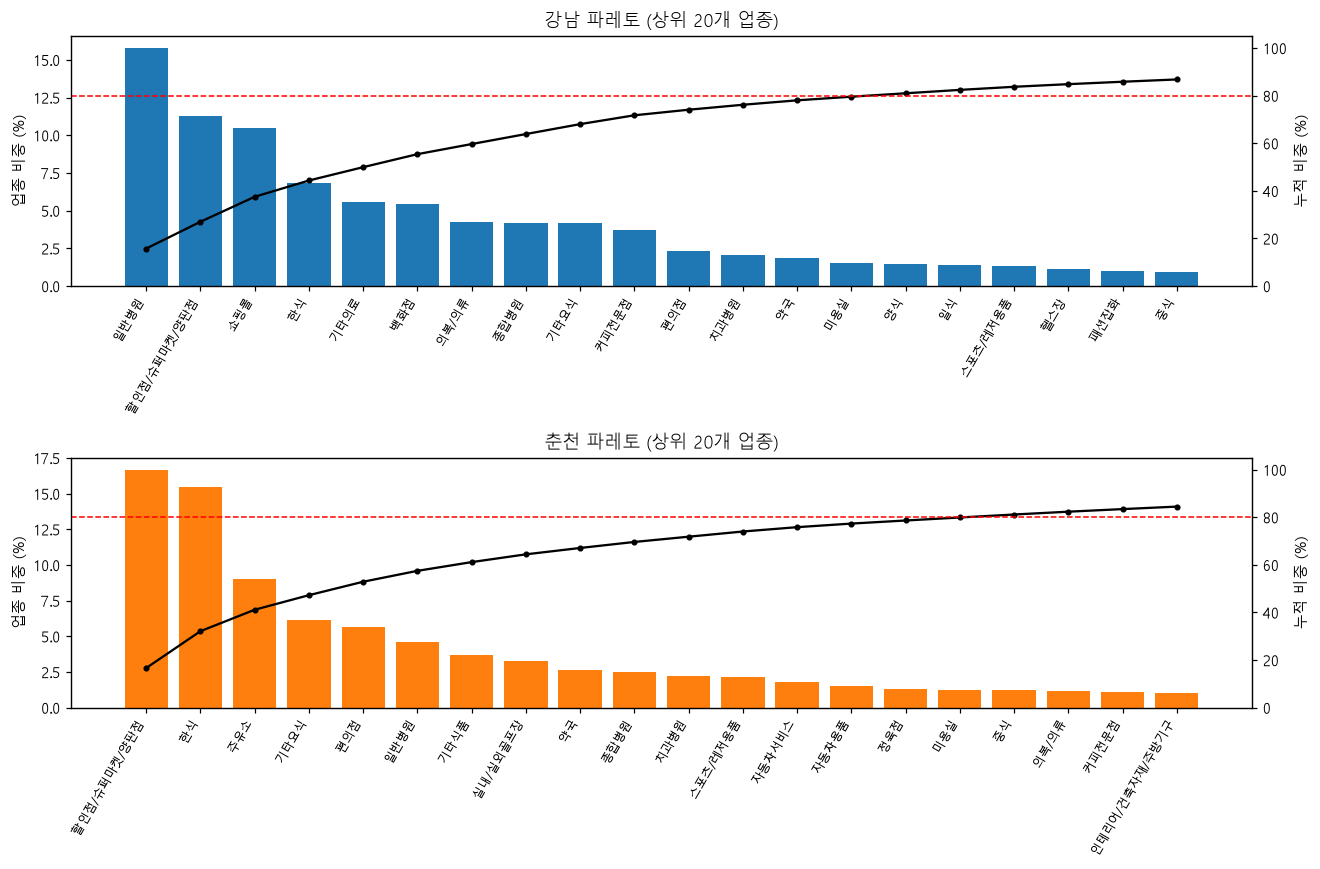

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, r in zip(axes, REGIONS):
    s = base1[base1['region'].eq(r)].groupby('industry')['amount'].sum().sort_values(ascending=False)
    share = s / s.sum()                             # 업종별 비중
    cum = share.cumsum()                            # 누적 비중: 위에서부터 차례로 더해 나감
    n80 = (cum < 0.8).sum() + 1                     # 누적 80%에 처음 도달하는 업종 수
    print(f'{r}: 업종 {len(s)}개 중 상위 {n80}개가 매출의 80%')
    print('   상위 5개:', ', '.join(f'{k} {v:.1%}' for k, v in share.head(5).items()))

    top = share.head(20)                            # 이름이 겹치지 않게 상위 20개만 그림
    ax.bar(range(len(top)), top * 100, color=REGION_COLOR[r])
    ax.set_xticks(range(len(top)), top.index, rotation=60, ha='right', fontsize=8)
    ax.set(ylabel='업종 비중 (%)', title=f'{r} 파레토 (상위 20개 업종)')
    ax2 = ax.twinx()                                # 오른쪽에 y축 하나 더 (누적 비중용)
    ax2.plot(range(len(top)), cum.head(20) * 100, color='black', marker='o', ms=3)
    ax2.axhline(80, ls='--', color='red', lw=1)
    ax2.set(ylabel='누적 비중 (%)', ylim=(0, 105))
plt.tight_layout()
plt.show()

시사점: 두 지역 모두 소수의 업종이 매출 대부분을 차지한다. <br>강남은 67개 업종 중 15개, 춘천은 66개 중 17개가 매출의 80%를 낸다. <br> 다만 상위 업종의 성격이 달라서, 강남은 일반병원(15.8%), 할인점/슈퍼마켓(11.3%), 쇼핑몰(10.5%) 같은 의료와 대형 유통이 앞서고, 춘천은 할인점/슈퍼마켓(16.7%), 한식(15.5%), 주유소(9.0%) 같은 장보기, 식사, 이동 관련 업종이 앞선다.

### 5-2. 업종그룹 구성 비교

region,강남,춘천
industry_group,,
의료,30.70,13.50
대형유통,16.30,0.50
음식점,15.90,26.50
식료품,12.50,22.60
패션/뷰티,6.60,2.30
생활/취미용품,4.60,6.30
카페,3.70,1.10
편의점,2.30,5.60
교통/차량,1.90,12.90


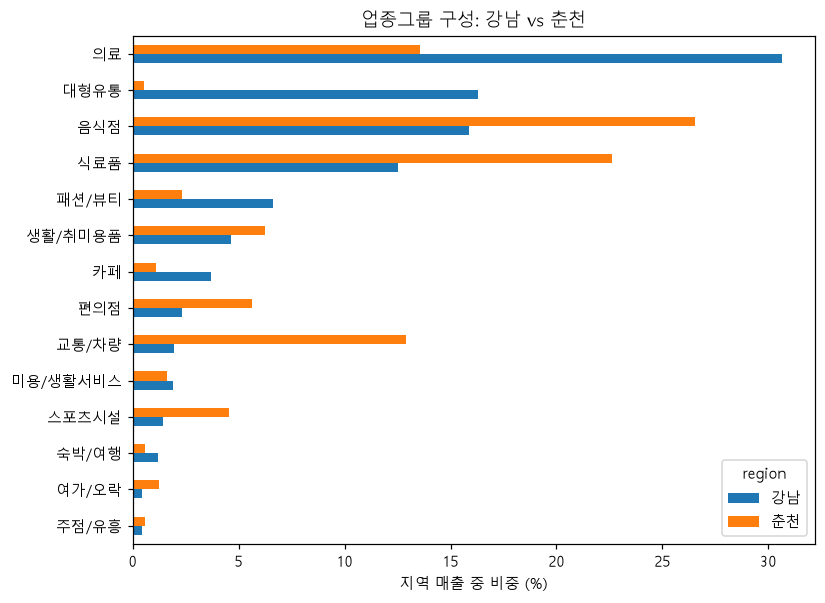

In [17]:
# 지역 × 업종그룹 금액 비중(%). 지역마다 합이 100
grp = base1.pivot_table(index='industry_group', columns='region', values='amount', aggfunc='sum')
grp_share = grp / grp.sum() * 100
grp_share = grp_share.sort_values('강남')          # 강남 비중 작은 것부터 -> barh에서 큰 것이 위로
display(grp_share.sort_values('강남', ascending=False).round(1))

ax = grp_share.plot(kind='barh', figsize=(8, 6), color=REGION_COLOR)
ax.set(xlabel='지역 매출 중 비중 (%)', ylabel='', title='업종그룹 구성: 강남 vs 춘천')
plt.show()

In [18]:
# 교통/차량 업종그룹에 어떤 업종이 들어 있는지, 지역별로 얼마나 차지하는지 확인
GROUP = '교통/차량'

# 1) 01번에서 정한 목록 (industry_map 기준)
print(f'{GROUP} 업종 목록:', ', '.join(industry_map.loc[industry_map['industry_group'].eq(GROUP), 'industry']))

# 2) 지역 × 업종별 금액(억 원)과, 그 지역 교통/차량 매출 안에서의 비중(%)
tv = (base1[base1['industry_group'].eq(GROUP)]
      .pivot_table(index='industry', columns='region', values='amount', aggfunc='sum', fill_value=0) / 1e8)   # fill_value=0: 없는 칸은 0
tv_share = tv / tv.sum() * 100                              # 지역마다 합이 100

result = pd.concat({'금액(억 원)': tv, '비중(%)': tv_share}, axis=1)   # 두 표를 옆으로 붙이기
display(result.sort_values(('금액(억 원)', '춘천'), ascending=False).round(1))   # 춘천 금액 큰 순서로


교통/차량 업종 목록: 택시, 고속버스/철도/여객선, 주차장, 주유소, 자동차서비스, 자동차용품, 오토바이


금액(억 원)          비중(%)      
region           강남       춘천    강남    춘천
industry                                
주유소          574.40 1,320.80 30.70 69.80
자동차서비스       395.10   268.00 21.10 14.20
자동차용품        141.30   220.50  7.50 11.70
택시            28.60    66.10  1.50  3.50
오토바이          18.20     9.10  1.00  0.50
주차장          100.50     4.40  5.40  0.20
고속버스/철도/여객선  615.30     3.40 32.80  0.20

시사점: 강남은 의료(30.7%)와 대형유통(16.3%)이 매출의 절반 가까이를 차지하고, 춘천은 음식점(26.5%), 식료품(22.6%), 교통/차량(12.9%, 대부분 주유소)이 중심이라 두 지역의 업종 구성이 크게 다르다. 특히 대형유통은 강남 16.3%, 춘천 0.5%로 거의 강남에만 있다. 그래서 두 지역의 매출 합계를 그대로 비교하면 날씨 효과가 아니라 업종 구성 차이가 섞인다. 따라서 지역별 매출 비교는 같은 업종그룹끼리 해야 한다.

### 5-3. 한쪽 지역에만 있는 업종

In [19]:
# 업종마다 등장하는 지역 목록 -> 지역이 1개뿐인 업종이 "한쪽에만 있는 업종"
regions_of = base1.groupby('industry')['region'].unique()          # 업종별로 나오는 지역 목록
only_one = regions_of[regions_of.str.len() == 1]                   # 지역이 1개인 업종만
display(only_one.str[0].rename('나오는 지역').to_frame())           # .str[0]: 목록의 첫 번째 값

,나오는 지역
industry,
면세점,강남
백화점,강남
종합레저타운/놀이동산,춘천


### 5-4. 업종별 날짜에 따른 일매출액 변동

강남 CV 작은 5개: 커피전문점 0.10, 패스트푸드 0.11, 주유소 0.12, 제과점 0.14, 한식 0.16
강남 CV 큰 5개:   수제용품점 1.26, 중고품판매점 1.21, 악기/음반 1.19, 기타의료 1.08, 면세점 1.01
춘천 CV 작은 5개: 편의점 0.08, 주유소 0.11, 패스트푸드 0.16, 커피전문점 0.17, 기타요식 0.20
춘천 CV 큰 5개:   쇼핑몰 4.64, 여행사/항공사 4.49, 주류판매 2.49, 악기/음반 1.94, 오토바이 1.72


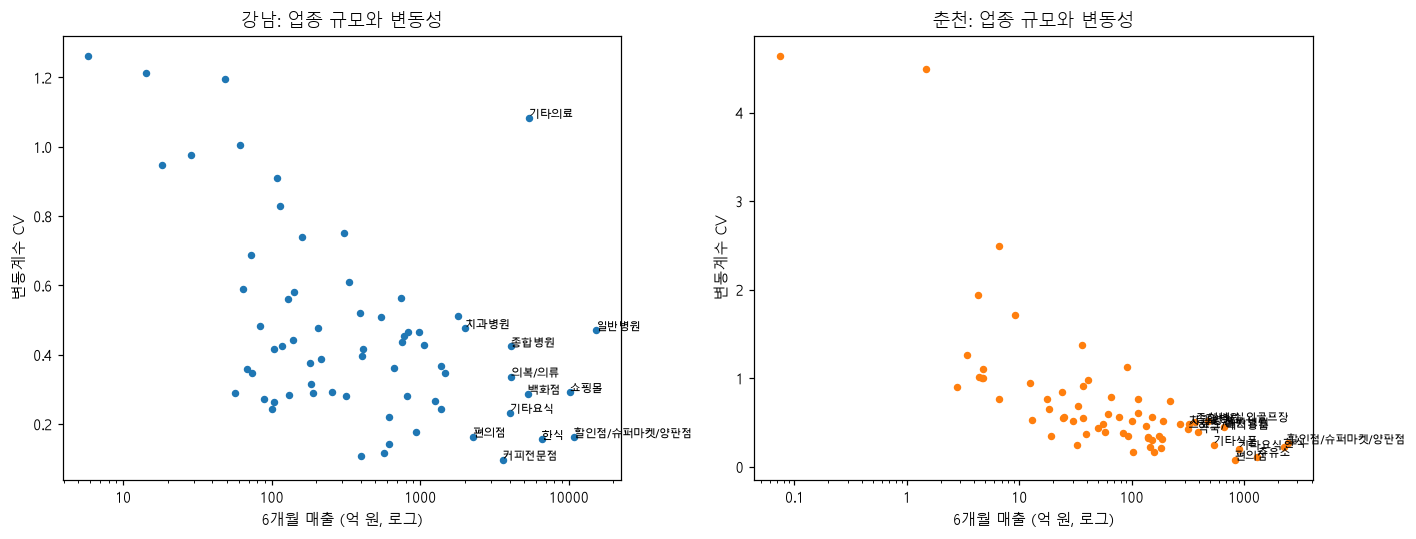

In [20]:
# 지역 × 업종 × 날짜별 금액 합계 -> 지역 × 업종별 변동계수(CV) = 표준편차 / 평균

# ex. 춘천시에 있는 모든 커피 업종 점포의 9/20일 매출액의 합
ind_daily = base1.groupby(['region', 'industry', 'date'])['amount'].sum()

cv = (
    # ex. 춘천시에 있는 모든 커피 업종 점포가 7/1부터 12/31까지 하루 매출 184개가 모임
    ind_daily.groupby(['region', 'industry'])
      .agg(총매출='sum', CV=lambda s: s.std() / s.mean())            # lambda: 이름 없는 짧은 함수
      .reset_index())
# 참고: 01번 3-2에서 0으로 채웠기 때문에 결제가 없던 날도 0으로 들어간다 (그만큼 CV가 커진다)

for r in REGIONS:
    t = cv[cv['region'].eq(r)]
    print(f'{r} CV 작은 5개:', ', '.join(f"{a} {b:.2f}" for a, b in t.nsmallest(5, 'CV')[['industry', 'CV']].values))
    print(f'{r} CV 큰 5개:  ', ', '.join(f"{a} {b:.2f}" for a, b in t.nlargest(5, 'CV')[['industry', 'CV']].values))

# 산점도: x = 규모(로그), y = CV. 오른쪽 아래 = 규모 크고 안정적 = 날씨 분석에 좋은 후보
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, REGIONS):
    t = cv[cv['region'].eq(r)]
    ax.scatter(t['총매출'] / 1e8, t['CV'], color=REGION_COLOR[r], s=15)
    for _, row in t.nlargest(12, '총매출').iterrows():                # 큰 업종 12개만 이름 달기
        ax.annotate(row['industry'], (row['총매출'] / 1e8, row['CV']), fontsize=7)
    ax.set_xscale('log')
    # 로그 축 눈금은 기본이 10⁻¹ 같은 수식 모양이라 한글 폰트에서 음수 기호가 깨짐 -> 보통 숫자(0.1, 1, 10)로 표시
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set(title=f'{r}: 업종 규모와 변동성', xlabel='6개월 매출 (억 원, 로그)', ylabel='변동계수 CV')
plt.tight_layout()
plt.show()

시사점: 커피전문점, 패스트푸드, 주유소, 편의점, 한식처럼 규모가 크고 날마다 매출이 고르게 나오는 일상 업종은 변동성이 낮아서, 날씨 때문에 생긴 작은 변화도 잡아내기 좋은 분석 후보다. 반대로 수제용품점, 악기/음반, 여행사/항공사처럼 규모가 작은 업종은 변동계수가 1을 넘어 원래 들쭉날쭉하므로 날씨 효과를 가려내기 어렵다.

### 5-5. 제외 업종 목록 다시 보기

,업종
exclude_reason,
고액/비일상 거래,"수입자동차, 중고차판매, 부동산중개, 예식장/결혼서비스, 장례식장/묘지/장의사"
공공기관,보건소
공과금/정기 납부,"세금공과금, 보험, 통신요금(이동,시내전화), 통신요금(PC통신,무선호출), LPG..."
기업/전문 서비스,"법률/사무서비스, 회계/변리서비스, 연구/번역서비스, 컴퓨터/소프트웨어"
분류 불명,"ZZ_나머지, 체인점"
중개/비대면성 결제,"결제대행(PG), 방문판매/다단계판매, 상품권/복권"


금액 큰 제외 업종 5개: ZZ_나머지, 세금공과금, 컴퓨터/소프트웨어, 보험, 학원/학습지


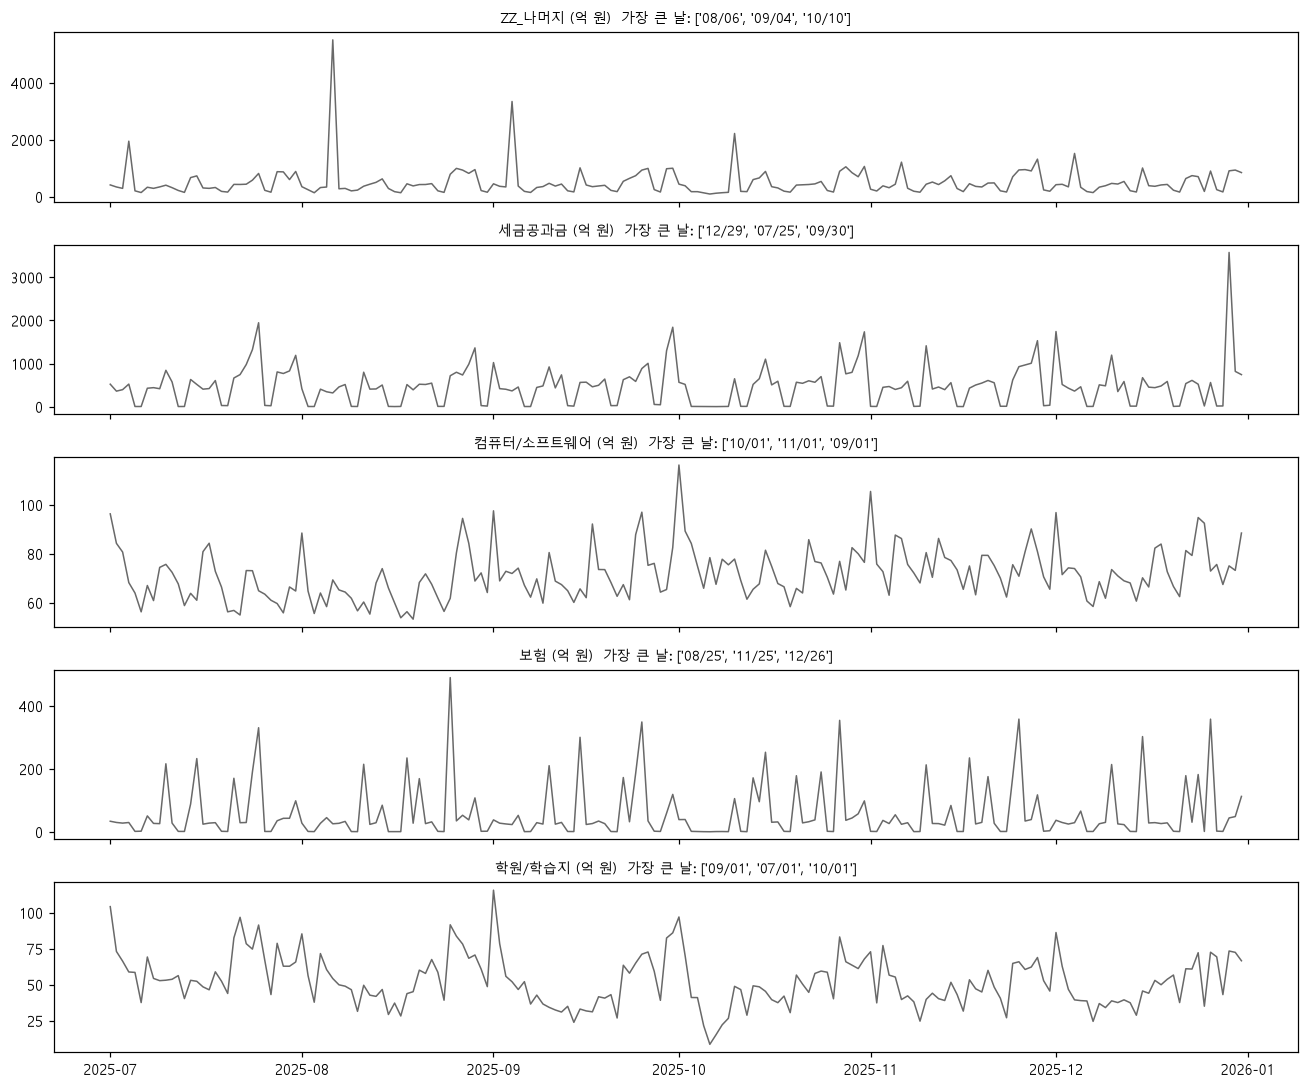

In [21]:
# 01번에서 정한 제외 업종과 제외 이유
excluded = industry_map[~industry_map['is_target']]
display(excluded.groupby('exclude_reason')['industry'].apply(', '.join).to_frame('업종'))

# 제외 업종 중 금액이 큰 5개의 일매출 -> 특정 날짜(납부일, 월말)에 몰리면 날씨와 무관하다는 근거
ex_amt = card1[~card1['is_target']].groupby('industry')['amount'].sum().nlargest(5)
print('금액 큰 제외 업종 5개:', ', '.join(ex_amt.index))
ex_daily = (card1[card1['industry'].isin(ex_amt.index)]
            .groupby(['date', 'industry'])['amount'].sum().unstack('industry') / 1e8)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, ind in zip(axes, ex_amt.index):
    ax.plot(ex_daily.index, ex_daily[ind], color='dimgray', lw=1)
    top_days = ex_daily[ind].nlargest(3).index.strftime('%m/%d').tolist()
    ax.set_title(f'{ind} (억 원)  가장 큰 날: {top_days}', fontsize=9)
plt.tight_layout()
plt.show()
# 판단이 애매한 업종이 있으면 아래 5장 정리에 메모하고, 바꾸려면 01번 3-1 사전을 고친 뒤 01번을 다시 실행

시사점: 제외 업종 중 금액이 큰 5개는 모두 매달 정해진 날짜에 매출이 몰린다(보험 25일, 학원과 소프트웨어 1일, 세금 월말, ZZ_나머지 4~6일). 날씨가 아니라 납부 일정을 따라 움직인다고 볼 수 있다. 따라서 날씨 분석에서 빼는 것이 맞다.

## 6. 업종 × 시간대

### 6-1. 지역별 시간대 비중

time_gb,00_05,06_11,12_17,18_23
region,,,,
강남,2.40,22.20,51.40,24.10
춘천,2.10,20.80,50.10,27.10


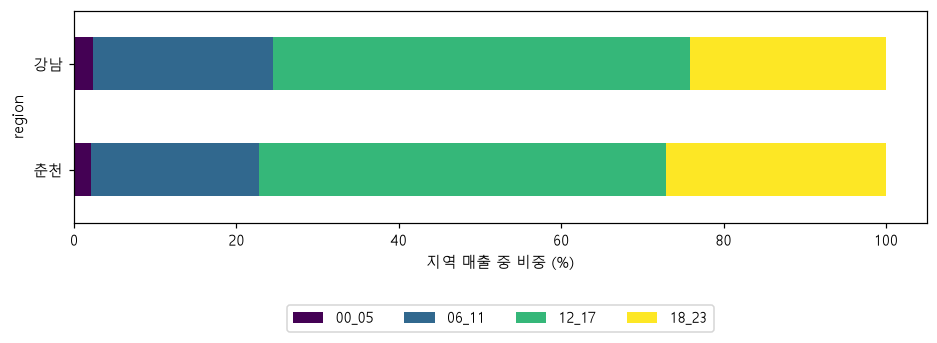

In [22]:
TIMES = ['00_05', '06_11', '12_17', '18_23']
# 지역 × 시간대 금액 비중(%). 지역마다 합이 100
tm = base1.pivot_table(index='region', columns='time_gb', values='amount', aggfunc='sum')[TIMES]
tm_share = tm.div(tm.sum(axis=1), axis=0) * 100
display(tm_share.round(1))

ax = tm_share.plot(kind='barh', stacked=True, figsize=(10, 2.5), colormap='viridis')
ax.set_xlabel('지역 매출 중 비중 (%)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=4)
ax.invert_yaxis()
plt.show()

시사점: 두 지역 모두 매출의 약 절반(강남 51.4%, 춘천 50.1%)이 12~17시에 나오고, 새벽(00~05시)은 2% 남짓이다. 춘천은 저녁(18~23시) 비중이 27.1%로 강남(24.1%)보다 조금 높다.<br>폭염 피크(14~16시)가 12_17 칸 안에 묻혀 있어서, 시간대로 더위 효과를 볼 때 가장 중요한 칸이지만 6시간 단위라 더 잘게 나눌 수는 없다.

### 6-2. 업종그룹 × 시간대 히트맵

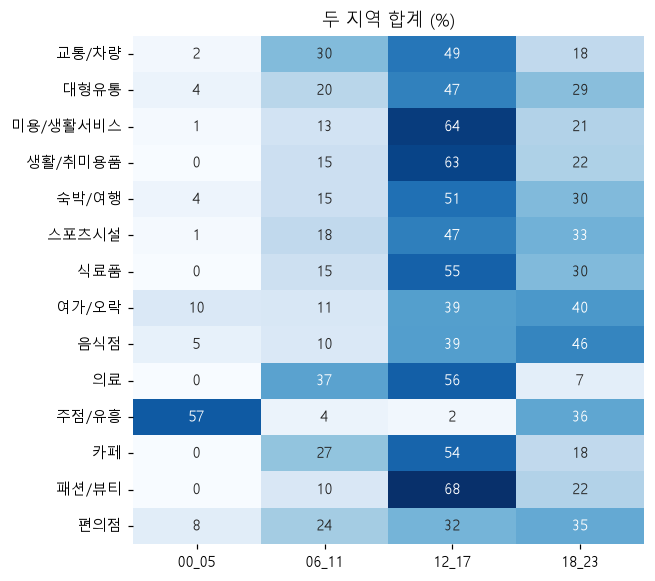

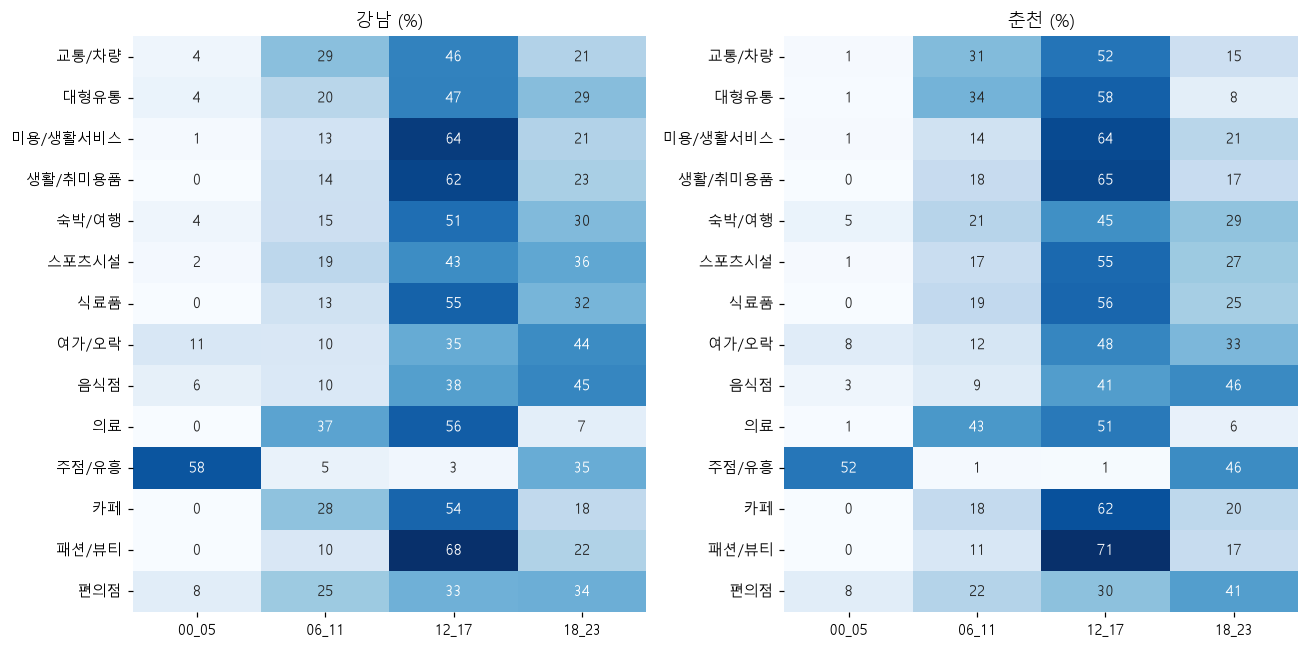

In [23]:
def time_heatmap(df, title, ax):
    """업종그룹 × 시간대 금액 비중(%) 히트맵. 업종그룹마다 합이 100."""

    # 업종그룹(행) × 시간대(열)로 금액을 모두 더한 표를 만들고, 시간대 열 순서를 00_05, 06_11, 12_17, 18_23으로 고정
    t = df.pivot_table(index='industry_group', columns='time_gb', values='amount', aggfunc='sum')[TIMES]
    t = t.div(t.sum(axis=1), axis=0) * 100
    sns.heatmap(t, annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar=False)   # annot=True: 칸 안에 숫자 쓰기
    ax.set(title=title, xlabel='', ylabel='')
    return t

fig, ax = plt.subplots(figsize=(6, 6))
time_share_grp = time_heatmap(base1, '두 지역 합계 (%)', ax)
plt.show()

# 같은 업종이라도 지역마다 시간대 패턴이 다른지
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, r in zip(axes, REGIONS):
    time_heatmap(base1[base1['region'].eq(r)], f'{r} (%)', ax)
plt.tight_layout()
plt.show()

시사점: 업종마다 매출이 나는 시간이 뚜렷하게 다르다. 주점/유흥은 새벽(00~05시 - 57%)과 저녁에 몰렸고, 음식점은 저녁(18~23시 - 46%), 의료는 오전과 오후(06~11시 - 37%, 저녁은 - 7%), 패션/뷰티는 오후(12~17시 - 68%)에 몰린다.<br>같은 업종이라도 지역마다 다른 곳이 있다. 대형유통은 강남에서 저녁 비중이 29%지만 춘천은 8%로 낮에 집중되고, 편의점과 주점/유흥은 춘천의 저녁 비중이 더 높다.<br>그래서 낮 더위와 밤 더위(열대야)가 영향을 주는 업종이 서로 다를 것으로 예상할 수 있다.

## 7. 성별 × 연령
누가 쓰는지 본다. 나중에 "고령층이 폭염에 더 민감한가"를 보려면 연령별 칸이 충분히 커야 한다.

### 7-1. 지역별 성별 × 연령 구성

sex       남성          여성      
region    강남    춘천    강남    춘천
age                           
10대     0.20  0.30  0.30  0.20
20대     3.20  4.60  6.70  4.80
30대    11.70 11.70 11.50  7.80
40대    13.80 13.80 13.00  9.10
50대    11.90 14.10 10.50 11.10
60대     6.20  8.80  5.40  7.40
70대     2.30  2.80  2.00  2.30
80대     0.70  0.70  0.50  0.50
90대     0.10  0.00  0.10  0.00

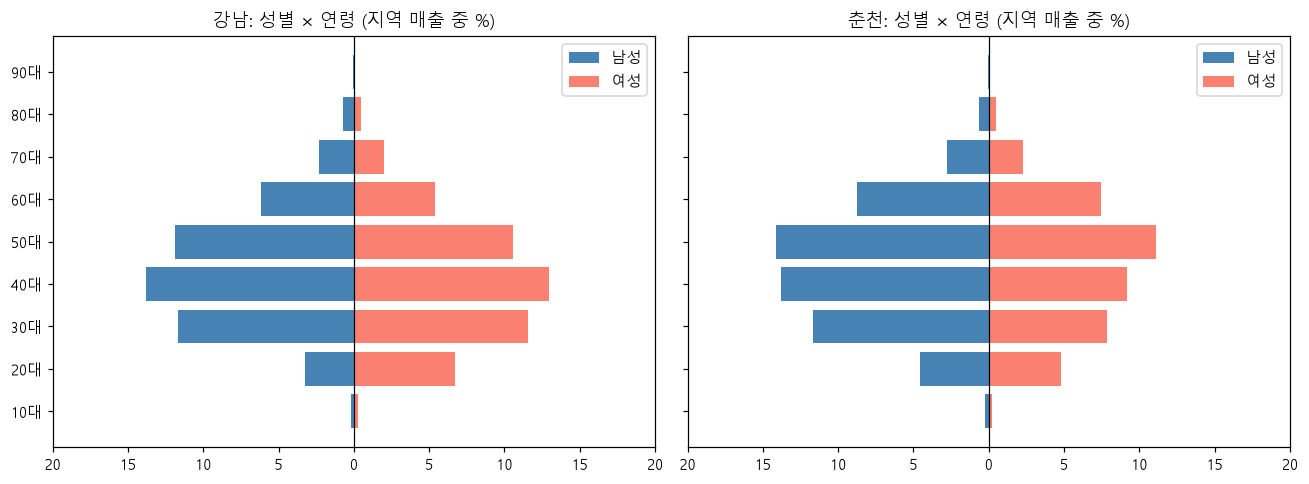

In [24]:
AGES = [f'{a}0대' for a in range(1, 10)]           # '10대', '20대', ..., '90대'

# 지역 × 성별 × 연령 조합별로 금액을 더한다.
sa = base1.groupby(['region', 'age', 'sex'])['amount'].sum()
# 행마다 그 지역전체 금액을 적는다. 지역이 같으면 금액 값이 같게 나옴
sa = sa / sa.groupby('region').transform('sum') * 100   
sa = sa.unstack('sex')                                   # 성별을 열로 펼치기 -> 열이 남성, 여성
display(sa.round(1).unstack('region'))

# 인구 피라미드: 왼쪽 남성(음수로 그림), 오른쪽 여성
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, r in zip(axes, REGIONS):
    t = sa.loc[r].reindex(AGES)
    ax.barh(AGES, -t['남성'], color='steelblue', label='남성')
    ax.barh(AGES, t['여성'], color='salmon', label='여성')
    ax.axvline(0, color='black', lw=0.8)
    lim = sa.max().max() * 1.1
    ax.set(title=f'{r}: 성별 × 연령 (지역 매출 중 %)', xlim=(-lim, lim))
    ax.set_xticks(ax.get_xticks(), [f'{abs(v):.0f}' for v in ax.get_xticks()])   # 음수 눈금을 양수로 표시
    ax.legend()
plt.tight_layout()
plt.show()

시사점: 두 지역 모두 30~50대가 매출의 대부분을 차지한다. 강남은 20대 여성 매출(6.7%)이 20대 남성(3.2%)의 약 2배로 젊은 여성 소비가 두드러지고, 춘천은 30~50대에서 남성 매출이 여성보다 많다(30대 11.7% vs 7.8%, 40대 13.8% vs 9.1%).<br>80대 이상은 성별마다 1% 미만이라, 고령층을 따로 보려면 연령을 묶어야 한다

### 7-2. 업종그룹 × 연령 히트맵

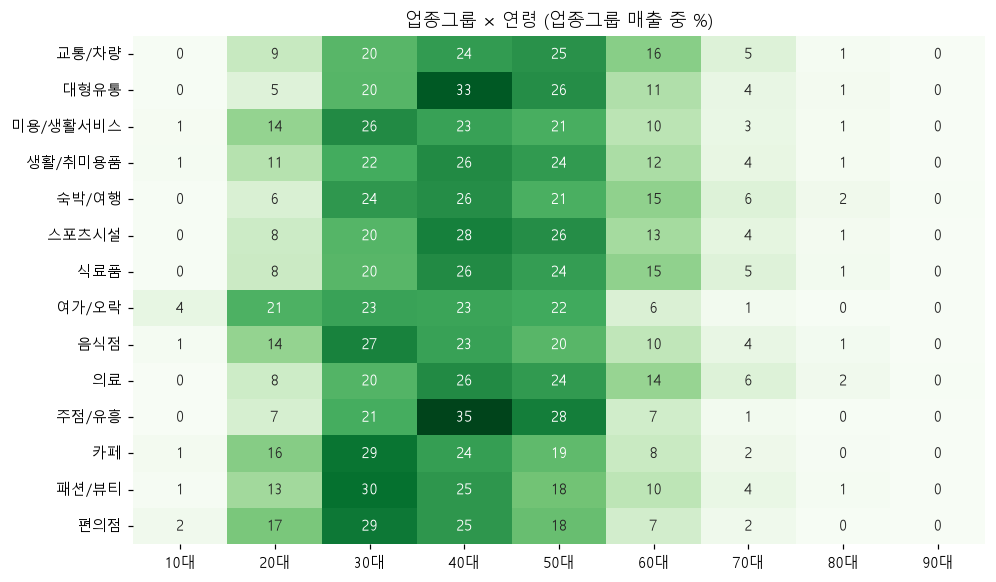

In [25]:
# 업종그룹 × 연령 금액 비중(%). 업종그룹마다 합이 100
ga = base1.pivot_table(index='industry_group', columns='age', values='amount', aggfunc='sum').reindex(columns=AGES)
ga = ga.div(ga.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ga, annot=True, fmt='.0f', cmap='Greens', ax=ax, cbar=False)
ax.set(title='업종그룹 × 연령 (업종그룹 매출 중 %)', xlabel='', ylabel='')
plt.show()

시사점: 업종마다 주 고객의 연령이 다르다. 20대 비중은 여가/오락(21%), 편의점(17%), 카페(16%)에서 높고 대형유통(5%), 숙박/여행(6%)에서 낮다. 60대 이상 비중은 숙박/여행, 식료품, 교통/차량, 의료(21~22%)에서 높고 여가/오락(8%), 주점/유흥(9%)에서 낮다.<br>"고령층이 폭염에 더 민감한가"를 볼 때는 60대 이상 비중이 높은 식료품, 의료 같은 업종에서 봐야 표본이 충분하다.

### 7-3. 연령 묶기 결정

In [26]:
# 연령별 0인 날 비중 (2-3과 같은 방법): 높으면 하루 단위로 들쭉날쭉한 연령
age_zero = base1.groupby('age')['is_filled'].mean().reindex(AGES)
display(age_zero.to_frame('0인 날 비중').map('{:.1%}'.format).T)

# 0인 날이 잦은 고령층을 묶는다. 아래는 예시 규칙이다. 서울 상권매출(04)도 '60대 이상'이라 비교하기 편함
AGE_GROUP = {'10대': '10대', '20대': '20대', '30대': '30대', '40대': '40대', '50대': '50대',
             '60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}

# 묶은 뒤의 0인 날 비중 확인
age_zero2 = (base1.assign(age_group=base1['age'].map(AGE_GROUP))
             .groupby('age_group')['is_filled'].mean())
display(age_zero2.to_frame('묶은 뒤 0인 날 비중').map('{:.1%}'.format).T)
print('AGE_GROUP =', AGE_GROUP)    # 05번 노트북에 옮겨 적는다

age,10대,20대,30대,40대,50대,60대,70대,80대,90대
0인 날 비중,53.2%,29.2%,23.3%,23.7%,24.9%,32.0%,42.6%,55.1%,73.6%


age_group,10대,20대,30대,40대,50대,60대 이상
묶은 뒤 0인 날 비중,53.2%,29.2%,23.3%,23.7%,24.9%,45.9%


AGE_GROUP = {'10대': '10대', '20대': '20대', '30대': '30대', '40대': '40대', '50대': '50대', '60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}


시사점: 20~50대는 매출의 83~88%가 184일 내내 남아 있는 칸에서 나오지만, 70대 52%, 80대 32%, 90대 12%로 나이가 많을수록 지워진 칸이 많다. 60대 이상을 하나로 묶으면 67%까지 올라가므로, 고령층 분석은 "60대 이상"으로 묶어서 하는 것이 안전하다. 10대(62%)도 칸이 작아 해석에 주의한다.

## 8. 법인 결제
법인 결제는 회식, 업무 출장처럼 **회사 일정**을 따라 움직여서 개인 소비와 성격이 다르다. 날씨 분석에서 뺄지 여기서 판단한다.

### 8-1. 법인 결제 규모와 업종

분석 대상 업종 금액 중 법인 비중: 16.1%
지역별: {'강남': '16.6%', '춘천': '13.0%'}


,법인,개인(base1)
industry_group,,
음식점,47.60,17.30
대형유통,7.20,14.20
식료품,7.00,13.90
숙박/여행,6.30,1.10
생활/취미용품,6.10,4.80
카페,6.00,3.40
교통/차량,5.50,3.40
의료,4.20,28.40
주점/유흥,2.60,0.40


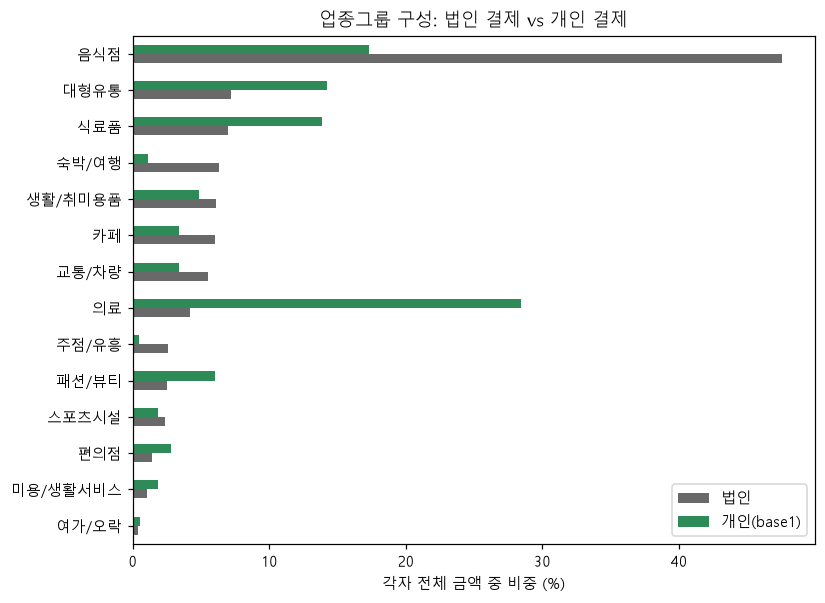

In [27]:
# 법인 결제 = 분석 대상 업종 중 sex가 '법인'인 행
corp = card1[card1['is_target'] & card1['sex'].eq('법인')]
target = card1[card1['is_target']]                          # 분석 대상 업종 전체 (개인 + 법인)

print(f"분석 대상 업종 금액 중 법인 비중: {corp['amount'].sum() / target['amount'].sum():.1%}")
by_region = corp.groupby('region')['amount'].sum() / target.groupby('region')['amount'].sum()
print('지역별:', by_region.map('{:.1%}'.format).to_dict())

# 업종그룹 구성(%): 법인 vs 개인
mix = pd.DataFrame({
    '법인': corp.groupby('industry_group')['amount'].sum(),
    '개인(base1)': base1.groupby('industry_group')['amount'].sum(),
})
mix = mix / mix.sum() * 100
mix = mix.sort_values('법인')
display(mix.sort_values('법인', ascending=False).round(1))

ax = mix.plot(kind='barh', figsize=(8, 6), color=['dimgray', 'seagreen'])
ax.set(xlabel='각자 전체 금액 중 비중 (%)', ylabel='', title='업종그룹 구성: 법인 결제 vs 개인 결제')
plt.show()

시사점: 분석 대상 업종 매출의 16.1%가 법인 결제다(강남 16.6%, 춘천 13.0%). 법인 결제의 절반 가까이(47.6%)가 음식점으로 개인(17.3%)보다 훨씬 몰려 있다(점심 식대인지 회식인지는 아래 보충에서 확인).숙박/여행도 출장 때문에 법인 쪽 비중이 높고(6.3% vs 1.1%), 의료는 대부분 개인 결제다(4.2% vs 28.4%).

#### 법인 음식점 결제는 점심 식대인가, 회식인가 (8-1 보충)
법인 결제의 절반이 음식점인데, 이게 **점심 식대**(식대를 법인카드로 주는 회사)인지 **저녁 회식이나 접대**인지 시간대로 나눠 본다.
- **건수**는 몇 번 결제했는지, **금액**은 얼마나 썼는지이다. 점심은 결제 횟수가 많고, 회식은 한 번에 크게 써서 금액이 크다.
- 시간대 칸이 6시간 단위라 12~17시가 순수한 점심은 아니다(11시대 점심은 06~11시 칸). 그래도 점심 결제의 대부분은 12~17시 칸에 들어간다.

두 지역 합계 (법인 vs 개인)


time_gb         00_05  06_11  12_17  18_23
            구분                            
건수 비중(%)    개인   2.10  19.30  51.50  27.20
            법인   1.10  18.20  53.20  27.50
금액 비중(%)    개인   5.40   9.90  39.00  45.70
            법인   4.00   9.10  36.30  50.60
1건당 금액(만 원) 개인   7.50   1.50   2.10   4.80
            법인  26.40   3.80   5.10  13.80

지역별 법인 음식점 결제 (각 지역 안에서 합이 100)


time_gb             00_05  06_11  12_17  18_23
            region                            
건수 비중(%)    강남       1.20  18.30  53.10  27.40
            춘천       0.60  16.10  54.90  28.30
금액 비중(%)    강남       4.30   8.90  35.80  51.00
            춘천       0.70  11.40  43.40  44.50
1건당 금액(만 원) 강남      27.10   3.60   5.00  13.90
            춘천       8.30   5.70   6.40  12.70

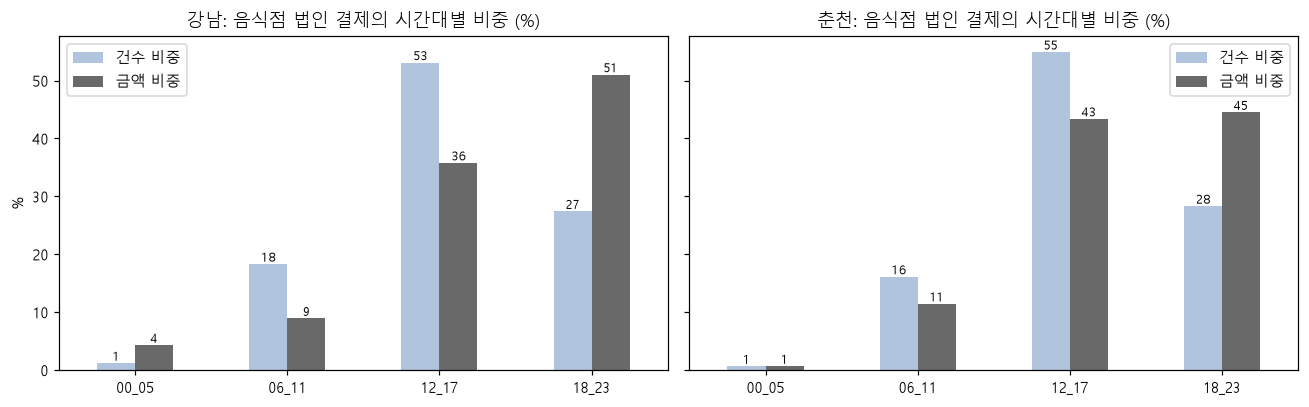

In [28]:
# 법인 음식점 결제가 점심(식대)인지 저녁(회식, 접대)인지, 시간대별 건수와 금액으로 확인한다.
# 건수는 "몇 번 결제했나", 금액은 "얼마나 썼나". 점심은 건수가 많고, 회식은 한 번에 크게 써서 금액이 큼
food = card1[card1['is_target'] & card1['industry_group'].eq('음식점')].copy()
food['구분'] = np.where(food['sex'].eq('법인'), '법인', '개인')      # np.where(조건, 참일 때, 거짓일 때)

#  1) 두 지역 합계: 법인과 개인 비교 
t = food.groupby(['구분', 'time_gb'])[['amount', 'cnt']].sum()
# transform('sum'): 행마다 "그 구분(법인 또는 개인)의 전체 합계"를 옆에 적어 줌 -> 나누면 비중
cnt_share = (t['cnt'] / t.groupby('구분')['cnt'].transform('sum') * 100).unstack('time_gb')[TIMES]
amt_share = (t['amount'] / t.groupby('구분')['amount'].transform('sum') * 100).unstack('time_gb')[TIMES]
ticket = (t['amount'] / t['cnt'] / 1e4).unstack('time_gb')[TIMES]           # 1건당 금액 (만 원)
print('두 지역 합계 (법인 vs 개인)')
display(pd.concat({'건수 비중(%)': cnt_share, '금액 비중(%)': amt_share, '1건당 금액(만 원)': ticket}).round(1))
# TIMES는 6-1에서 정한 시간대 순서 ['00_05', '06_11', '12_17', '18_23']

#  2) 지역별: 법인 결제만 
corp_food = food[food['구분'].eq('법인')]
r_t = corp_food.groupby(['region', 'time_gb'])[['amount', 'cnt']].sum()
r_cnt = (r_t['cnt'] / r_t.groupby('region')['cnt'].transform('sum') * 100).unstack('time_gb')[TIMES]
r_amt = (r_t['amount'] / r_t.groupby('region')['amount'].transform('sum') * 100).unstack('time_gb')[TIMES]
r_ticket = (r_t['amount'] / r_t['cnt'] / 1e4).unstack('time_gb')[TIMES]
print('지역별 법인 음식점 결제 (각 지역 안에서 합이 100)')
display(pd.concat({'건수 비중(%)': r_cnt, '금액 비중(%)': r_amt, '1건당 금액(만 원)': r_ticket}).round(1))

# 그래프: 왼쪽 강남, 오른쪽 춘천. 막대 색은 건수 비중(연한 파랑)과 금액 비중(진한 회색)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)       # sharey: 두 칸의 y축 눈금을 같게
for ax, r in zip(axes, REGIONS):
    pd.DataFrame({'건수 비중': r_cnt.loc[r], '금액 비중': r_amt.loc[r]}).plot(
        kind='bar', ax=ax, color=['lightsteelblue', 'dimgray'], rot=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f', fontsize=8)      # 막대 위에 숫자
    ax.set(title=f'{r}: 음식점 법인 결제의 시간대별 비중 (%)', xlabel='', ylabel='%')
plt.tight_layout()
plt.show()

시사점: 음식점 법인 결제는 **건수로는 12~17시가 53%로 점심 식대가 가장 많고**, **금액으로는 18~23시가 51%로 저녁 회식과 접대가 절반**을 차지한다. 저녁 법인 결제는 1건에 약 13.8만 원으로 점심(약 5.1만 원)의 2.7배라, 횟수는 적어도 한 번에 크게 쓴다.<br>법인과 개인의 시간대별 건수 비중은 거의 같고(12~17시 53% vs 52%), 차이는 1건당 금액(법인이 개인의 약 2.5~3배)에서 난다. 법인 결제는 여러 명 몫을 한 번에 결제하는 경우가 많기 때문으로 보인다.<br>지역별로 보면 건수는 두 지역 모두 12~17시가 53~55%로 비슷하지만, 금액은 강남이 저녁 51%로 저녁에 더 몰리고 춘천은 점심(43%)과 저녁(45%)이 비슷하다. 강남은 저녁 회식과 접대의 비중이 더 크고, 춘천은 점심 식대의 비중이 상대적으로 크다.

### 8-2. 법인 결제의 요일 패턴

법인: 쉬는 날 / 평일 = 0.31
개인: 쉬는 날 / 평일 = 0.82


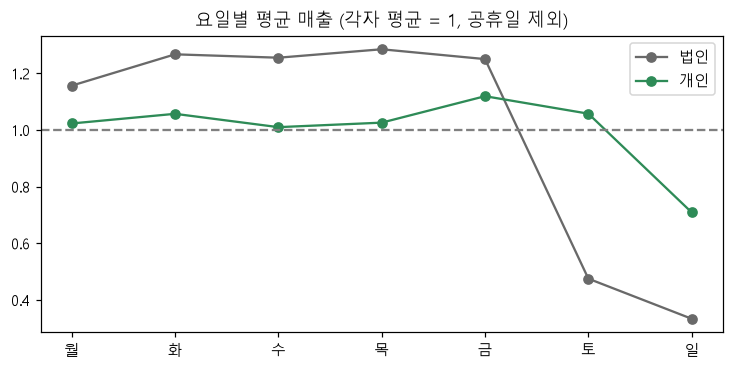

In [29]:
# 일별 합계에 달력 붙이기
corp_day = corp.groupby('date')['amount'].sum().rename('법인').to_frame().join(cal)
pers_day = base1.groupby('date')['amount'].sum().rename('개인').to_frame().join(cal)

# 쉬는 날 평균 / 평일 평균
for name, d in [('법인', corp_day), ('개인', pers_day)]:
    ratio = d.loc[d['is_offday'], name].mean() / d.loc[~d['is_offday'], name].mean()
    print(f'{name}: 쉬는 날 / 평일 = {ratio:.2f}')

# 요일별 평균 (공휴일 제외, 각자 전체 평균 = 1)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, d, color in [('법인', corp_day, 'dimgray'), ('개인', pers_day, 'seagreen')]:
    d = d[~d['is_holiday']]
    prof = d.groupby('dow')[name].mean() / d[name].mean()
    ax.plot(DOW, prof.values, marker='o', color=color, label=name)
ax.axhline(1, ls='--', color='gray')
ax.set(title='요일별 평균 매출 (각자 평균 = 1, 공휴일 제외)')
ax.legend()
plt.show()

시사점: 법인 결제는 평일에 평균의 1.2~1.3배이다가 토요일 0.48배, 일요일 0.33배로 떨어져, 쉬는 날 매출이 평일의 31%뿐이다. 개인 결제는 쉬는 날에도 평일의 82% 수준이다.<br>법인 결제는 날씨보다 회사 일정을 따라 움직여서, 날씨 분석에 섞으면 요일 효과가 커지고 날씨 효과가 흐려진다. 기본 분석은 개인 결제만 쓰는 것이 합리적이다.

**결정**: 날씨 분석에서 법인 결제를 뺄지 적어 둔다. (예: "기본 분석은 개인 결제만, 법인은 음식점에 한해 참고용으로만 본다")

- 결정:
- 이유:

## 9. 고객 거주지 (카드 데이터2 전용)
카드 데이터2는 데이터1과 같은 결제를 **고객 거주지(시도)** 로 나눈 것이다(01번 2-2에서 확인). 그래서 이 장에서는 거주지 축만 본다.

**외지인 정의**
- 춘천: 거주지가 `강원`이 아닌 고객
- 강남: 거주지가 `서울`이 아닌 고객
- `정보없음`은 외지인에서 뺀다 (전체의 0.1% 정도)

> 강남의 "외지인" 대부분은 경기, 인천에서 오는 **출퇴근 인구**라서 관광객과 성격이 다르다. 강남은 "수도권 밖" 기준도 같이 본다.

### 9-1. 거주지 구성

강남 상위 5개: 서울 52.0%, 경기 24.3%, 인천 4.0%, 전남광주 2.6%, 부산 2.3%
춘천 상위 5개: 강원 81.5%, 경기 7.8%, 서울 6.9%, 인천 1.1%, 충북 0.5%


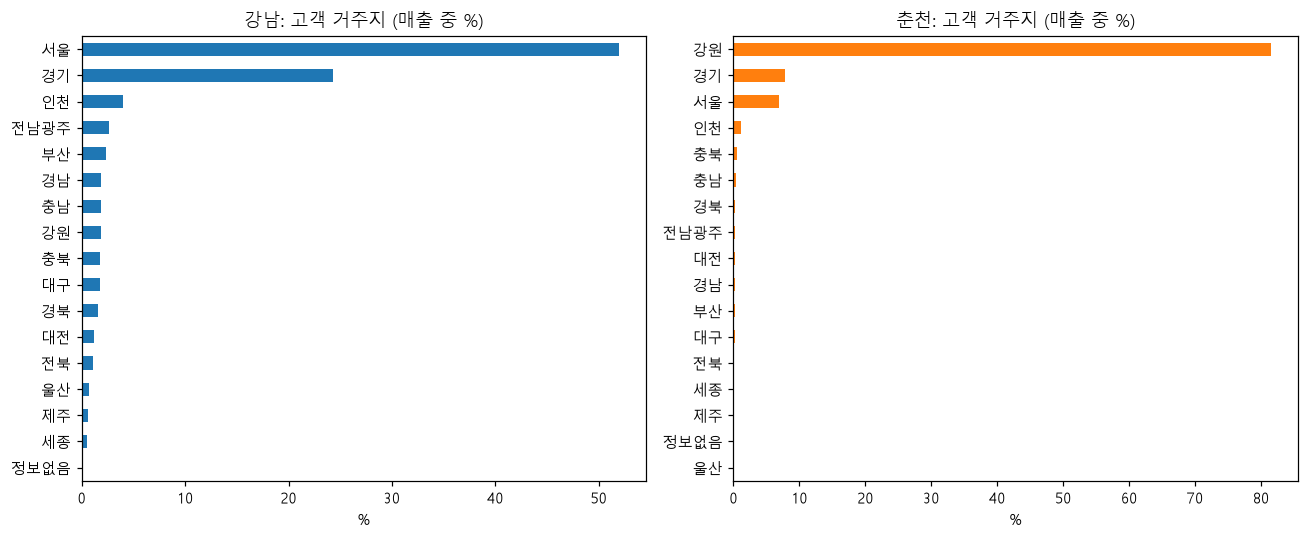

In [30]:
# 지역 × 거주지 금액 비중(%). 지역마다 합이 100
res = base2.pivot_table(index='residence', columns='region', values='amount', aggfunc='sum')
res_share = res / res.sum() * 100

for r in REGIONS:
    print(f'{r} 상위 5개:', ', '.join(f'{k} {v:.1f}%' for k, v in res_share[r].nlargest(5).items()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, r in zip(axes, REGIONS):
    res_share[r].sort_values().plot(kind='barh', ax=ax, color=REGION_COLOR[r])
    ax.set(title=f'{r}: 고객 거주지 (매출 중 %)', xlabel='%', ylabel='')
plt.tight_layout()
plt.show()

시사점: 춘천 매출의 81.5%는 강원 거주자에게서 나오고, 외지인은 대부분 수도권(경기 7.8%, 서울 6.9%, 인천 1.1%)이다. 강남은 서울 거주자가 52.0%뿐이고 경기(24.3%), 인천(4.0%)이 많아, 매출의 절반 가까이가 서울 밖 고객에게서 나온다.

### 9-2. 외지인 표시 열 만들기

In [31]:
# 지역별 "현지" 시도. 거주지가 여기가 아니면 외지인
LOCAL = {'강남': '서울', '춘천': '강원'}

# 외지인 = 거주지가 현지 시도가 아니고, '정보없음'도 아님
base2['is_outsider'] = (base2['residence'].ne(base2['region'].map(LOCAL))   # map: 행마다 지역에 맞는 현지 시도를 가져옴
                        & base2['residence'].ne('정보없음'))
# 강남용: 수도권(서울, 경기, 인천) 밖에서 온 고객. 강남 "외지인"의 대부분이 출퇴근 인구라서 따로 봄
base2['is_outside_capital'] = ~base2['residence'].isin(['서울', '경기', '인천', '정보없음'])

check = base2.groupby('region').apply(
    lambda d: pd.Series({
        '외지인 비중': d.loc[d['is_outsider'], 'amount'].sum() / d['amount'].sum(),
        '수도권 밖 비중': d.loc[d['is_outside_capital'], 'amount'].sum() / d['amount'].sum(),
    }), include_groups=False)
display(check.map('{:.1%}'.format))

,외지인 비중,수도권 밖 비중
region,,
강남,47.9%,19.7%
춘천,18.4%,84.1%


시사점: 외지인 매출 비중은 강남 47.9%, 춘천 18.4%다. 다만 이 기준은 거주지가 다른 시도인지만 보기때문에 방문 목적은 알 수 없다. 강남 외지인의 대부분은 경기(24.3%)와 인천(4.0%)이고, 출퇴근하는 사람과 놀러 온 사람이 섞여 있을 수 있다.

### 9-3. 일별 외지인 비중 추이

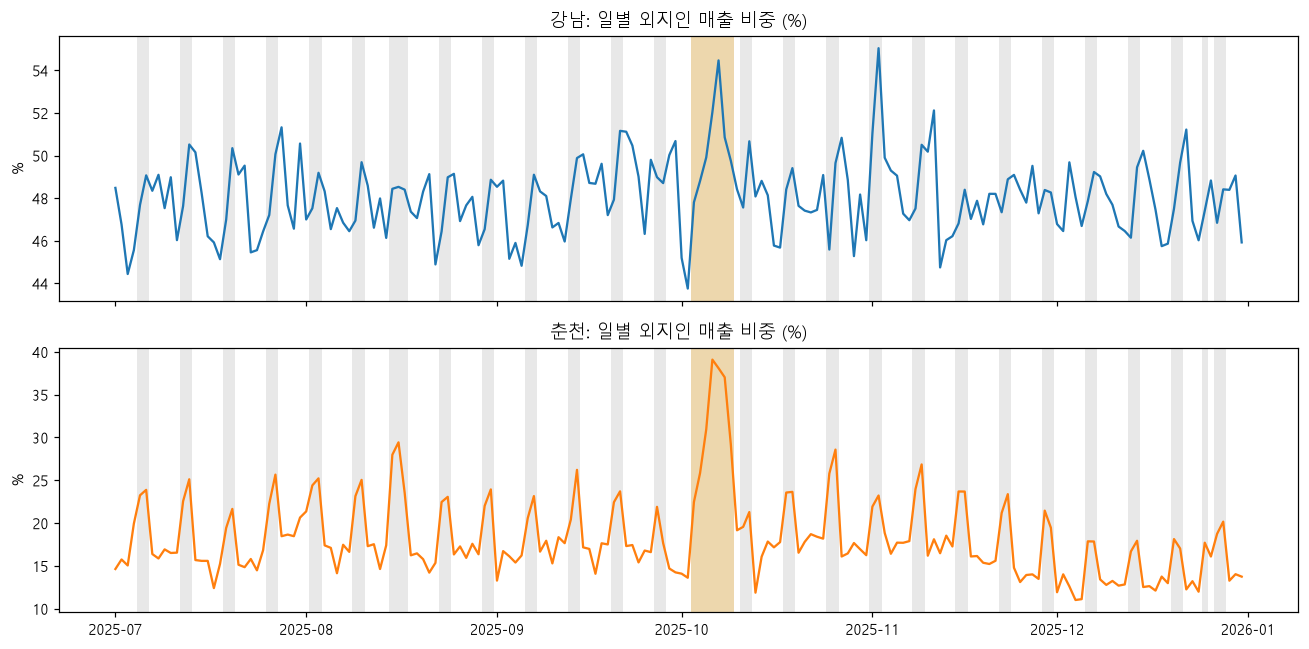

,평일,쉬는 날,추석 연휴,최대
강남,47.7%,48.8%,50.5%,55.0%
춘천,15.8%,23.5%,31.8%,39.1%


In [32]:
# 지역 × 날짜별 외지인 비중 = 외지인 금액 / 전체 금액
base2['amount_outsider'] = base2['amount'] * base2['is_outsider']        # True=1, False=0 을 곱하면 외지인 금액만 남음
g = base2.groupby(['date', 'region'])[['amount', 'amount_outsider']].sum()
out_share = (g['amount_outsider'] / g['amount']).unstack('region')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, r in zip(axes, REGIONS):
    shade_days(ax)
    ax.plot(out_share.index, out_share[r] * 100, color=REGION_COLOR[r])
    ax.set(title=f'{r}: 일별 외지인 매출 비중 (%)', ylabel='%')
plt.tight_layout()
plt.show()

# 평일, 쉬는 날, 추석 연휴의 평균 비중
os_cal = out_share.join(cal)
summary = pd.DataFrame({
    '평일':      os_cal.loc[~os_cal['is_offday'], REGIONS].mean(),
    '쉬는 날':   os_cal.loc[os_cal['is_offday'], REGIONS].mean(),
    '추석 연휴': os_cal.loc[os_cal['is_chuseok_break'], REGIONS].mean(),
    '최대':      os_cal[REGIONS].max(),
})
display(summary.map('{:.1%}'.format))

시사점: 춘천의 외지인 비중은 평일 15.8%에서 쉬는 날 23.5%, 추석 연휴 31.8%로 오르고, 가장 높은 날은 39.1%다. 주말과 연휴에 외지인이 몰리는 관광형이다. 반면 강남은 평일 47.7%, 쉬는 날 48.8%, 추석 50.5%로 거의 변하지 않는다.

### 9-4. 업종별 외지인 의존도

,강남,춘천
industry_group,,
숙박/여행,0.40,0.75
스포츠시설,0.20,0.61
여가/오락,0.31,0.48
음식점,0.34,0.24
카페,0.63,0.20
편의점,0.30,0.18
주점/유흥,0.32,0.14
대형유통,0.57,0.13
교통/차량,0.47,0.13


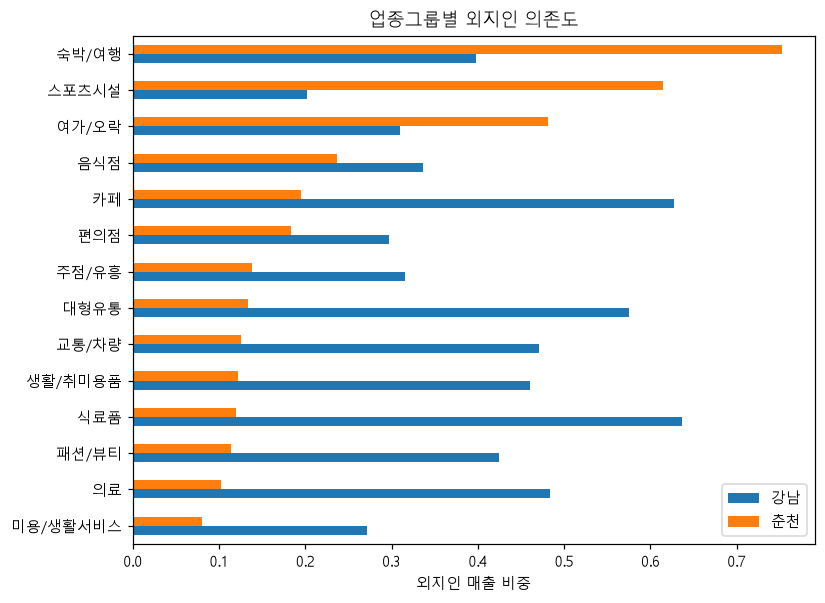

,춘천 업종별 외지인 비중
industry,
종합레저타운/놀이동산,0.80
실내/실외골프장,0.78
한식,0.26
기타요식,0.23
기타식품,0.22
양식,0.20
커피전문점,0.20
편의점,0.18
일식,0.18


In [33]:
def outsider_share(df, by):
    """by(업종그룹 또는 업종)별 외지인 금액 비중."""
    t = df.groupby(by)[['amount', 'amount_outsider']].sum()
    return t['amount_outsider'] / t['amount']

# 지역 × 업종그룹 외지인 비중
grp_out = pd.DataFrame({r: outsider_share(base2[base2['region'].eq(r)], 'industry_group') for r in REGIONS})
grp_out = grp_out.sort_values('춘천')
display(grp_out.sort_values('춘천', ascending=False).round(2))

ax = grp_out.plot(kind='barh', figsize=(8, 6), color=REGION_COLOR)
ax.set(xlabel='외지인 매출 비중', ylabel='', title='업종그룹별 외지인 의존도')
plt.show()

# 춘천만 업종 단위로 (춘천 전체 금액의 0.5% 이상인 업종만. 너무 작은 업종은 값이 불안정해서 뺌)
cc = base2[base2['region'].eq('춘천')]
ind_amt = cc.groupby('industry')['amount'].sum()
big = ind_amt[ind_amt / ind_amt.sum() >= 0.005].index
cc_ind = outsider_share(cc[cc['industry'].isin(big)], 'industry').sort_values(ascending=False)
display(cc_ind.round(2).to_frame('춘천 업종별 외지인 비중'))

시사점: 춘천은 숙박/여행(0.75), 스포츠시설(0.61), 여가/오락(0.48)의 외지인 비중이 높고, 업종으로 보면 종합레저타운/놀이동산(0.80)과 실내/실외골프장(0.78)은 매출 대부분이 외지인이다. 날씨 때문에 외지인이 오지 않으면 매출이 크게 흔들릴 수 있어, 날씨 영향을 가장 크게 받을 후보다.<br>강남은 식료품(0.64), 카페(0.63), 대형유통(0.57)의 외지인 비중이 높은데, 출퇴근 인구가 쓰는 업종으로 보인다.

### 9-5. 외지인은 누구인가 (연령)

age,10대,20대,30대,40대,50대,60대,70대,80대,90대
구분,,,,,,,,,
외지인,0.70,12.40,20.50,23.20,25.30,13.90,3.40,0.60,0.00
현지인,0.50,8.70,19.30,22.90,25.20,16.70,5.40,1.20,0.10


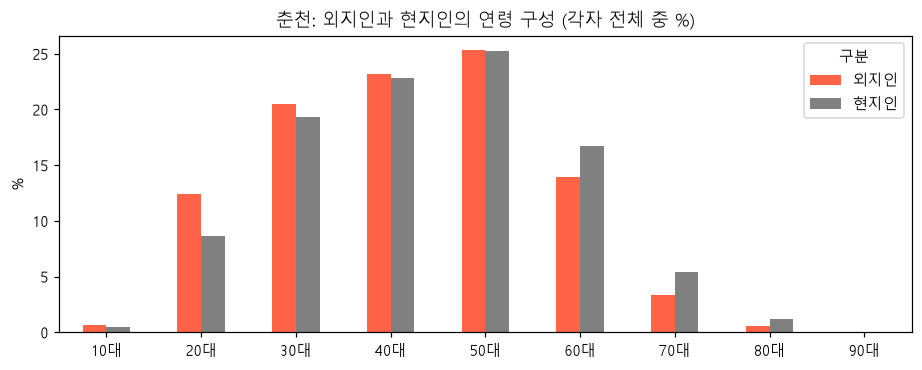

In [34]:
# 춘천: 외지인과 현지인의 연령 구성(%)
cc_age = (cc.assign(구분=np.where(cc['is_outsider'], '외지인', '현지인'))    # np.where(조건, 참일 때, 거짓일 때)
          .pivot_table(index='age', columns='구분', values='amount', aggfunc='sum')
          .reindex(AGES))
cc_age = cc_age / cc_age.sum() * 100
display(cc_age.round(1).T)

ax = cc_age.plot(kind='bar', figsize=(10, 3.5), color=['tomato', 'gray'], rot=0)
ax.set(title='춘천: 외지인과 현지인의 연령 구성 (각자 전체 중 %)', xlabel='', ylabel='%')
plt.show()

시사점: 춘천 외지인은 현지인보다 20대 비중이 높고(12.4% vs 8.7%) 60대 이상 비중이 낮다(17.9% vs 23.4%). 30~50대 비중은 비슷해서, 외지인이 조금 더 젊은 편이지만 연령 구성 차이가 크지는 않다.

### 9-6. 05번에 넘길 표 저장

In [35]:
# 날짜 × 지역 × 업종그룹별 전체 금액과 외지인 금액 -> 05번에서 날씨와 붙여서 씀
card2_outsider_daily = (base2.groupby(['date', 'region', 'industry_group'], as_index=False)
                        .agg(amount_total=('amount', 'sum'), amount_outsider=('amount_outsider', 'sum')))
# as_index=False: 묶은 열(date, region, industry_group)을 행 이름이 아닌 보통 열로 남김
card2_outsider_daily['outsider_share'] = card2_outsider_daily['amount_outsider'] / card2_outsider_daily['amount_total']

card2_outsider_daily.to_parquet(OUT / 'card2_outsider_daily.parquet', index=False)
print(f'저장: card2_outsider_daily.parquet  {len(card2_outsider_daily):,}행 × {card2_outsider_daily.shape[1]}열')
print('184일 × 2지역 × 업종그룹 수 =', 184 * 2 * base2['industry_group'].nunique())
display(card2_outsider_daily.head())

저장: card2_outsider_daily.parquet  5,152행 × 6열
184일 × 2지역 × 업종그룹 수 = 5152


,date,region,industry_group,amount_total,amount_outsider,outsider_share
0,2025-07-01,강남,교통/차량,1223980109,567300276,0.46
1,2025-07-01,강남,대형유통,8585365243,5394847882,0.63
2,2025-07-01,강남,미용/생활서비스,1042515721,350353715,0.34
3,2025-07-01,강남,생활/취미용품,2441970176,1048796574,0.43
4,2025-07-01,강남,숙박/여행,482014597,199097627,0.41
